## Potential Talents - Part 1

**Background:**
As a talent sourcing and management company, we are interested in finding talented individuals for sourcing these candidates to technology companies. Finding talented candidates is not easy, for several reasons. The first reason is one needs to understand what the role is very well to fill in that spot, this requires understanding the client’s needs and what they are looking for in a potential candidate. The second reason is one needs to understand what makes a candidate shine for the role we are in search for. Third, where to find talented individuals is another challenge.

The nature of our job requires a lot of human labor and is full of manual operations. Towards automating this process we want to build a better approach that could save us time and finally help us spot potential candidates that could fit the roles we are in search for. Moreover, going beyond that for a specific role we want to fill in we are interested in developing a machine learning powered pipeline that could spot talented individuals, and rank them based on their fitness.

We are right now semi-automatically sourcing a few candidates, therefore the sourcing part is not a concern at this time but we expect to first determine best matching candidates based on how fit these candidates are for a given role. We generally make these searches based on some keywords such as “full-stack software engineer”, “engineering manager” or “aspiring human resources” based on the role we are trying to fill in. These keywords might change, and you can expect that specific keywords will be provided to you.

Assuming that we were able to list and rank fitting candidates, we then employ a review procedure, as each candidate needs to be reviewed and then determined how good a fit they are through manual inspection. This procedure is done manually and at the end of this manual review, we might choose not the first fitting candidate in the list but maybe the 7th candidate in the list. If that happens, we are interested in being able to re-rank the previous list based on this information. This supervisory signal is going to be supplied by starring the 7th candidate in the list. Starring one candidate actually sets this candidate as an ideal candidate for the given role. Then, we expect the list to be re-ranked each time a candidate is starred.

**Data Description:**

The data comes from our sourcing efforts. We removed any field that could directly reveal personal details and gave a unique identifier for each candidate.

**Attributes:**
- id : unique identifier for candidate (numeric)
- job_title : job title for candidate (text)
- location : geographical location for candidate (text)
- connections: number of connections candidate has, 500+ means over 500 (text)
- Output (desired target):
- fit - how fit the candidate is for the role? (numeric, probability between 0-1)
- Keywords: “Aspiring human resources” or “seeking human resources”

**Goal(s):**
Predict how fit the candidate is based on their available information (variable fit)

**Success Metric(s):**
- Rank candidates based on a fitness score.
- Re-rank candidates when a candidate is starred.

**Current Challenges:**
- We are interested in a robust algorithm, tell us how your solution works and show us how your ranking gets better with each starring action.
- How can we filter out candidates which in the first place should not be in this list?
- Can we determine a cut-off point that would work for other roles without losing high potential candidates?
- Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?


----


### 1. EDA

In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/MLProjects/HRSourcing/potential-talents.csv')

In [5]:
df.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB


In [7]:
df.shape

(104, 5)

In [8]:
df['fit'].unique()

array([nan])

### Distribution of `connection`

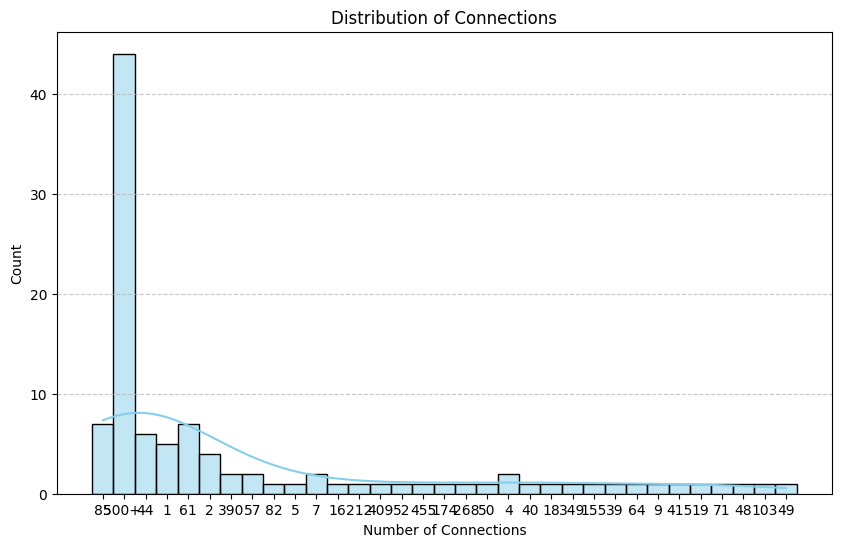

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['connection'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Connections')
plt.xlabel('Number of Connections')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Dominant '500+' Category:** The most prominent bar is for '500+' connections. This indicates that a significant portion of the candidates in your dataset are highly networked, with over 500 connections. This could suggest they are experienced professionals or very active on their platform.
**Lower Connection Counts:** There are also smaller peaks for lower connection ranges, showing that some candidates have fewer connections (e.g., 0-100, 100-200, etc.). This means your dataset includes a mix of individuals, from those just starting out or less active in networking to highly connected professionals.
**Implication:** The distribution suggests a dataset heavily skewed towards well-connected individuals, which might be beneficial for sourcing, as higher connections can sometimes correlate with experience or influence. However, it's also important to consider if this bias in connection numbers aligns with the target roles you're trying to fill.

### Top 10 Most Frequent `location` Values

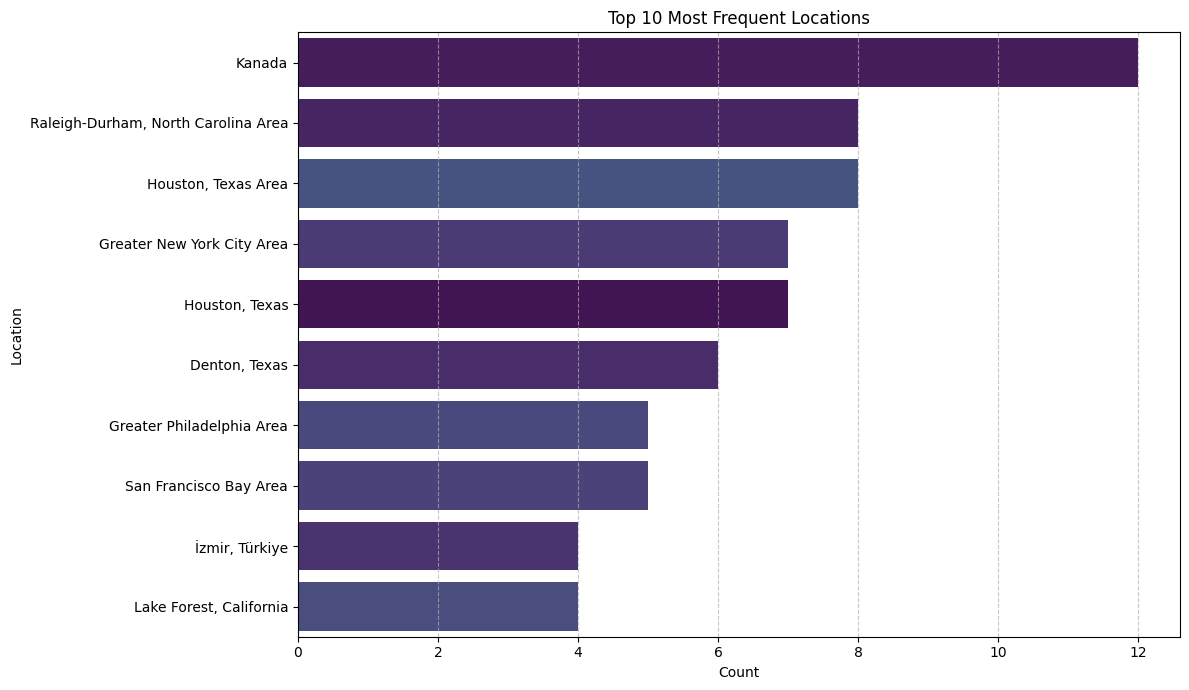

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='location', order=df['location'].value_counts().index[:10], palette='viridis', hue='location', legend=False)
plt.title('Top 10 Most Frequent Locations')
plt.xlabel('Count')
plt.ylabel('Location')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The bar chart visualizing the 'Top 10 Most Frequent Locations' reveals some interesting patterns about the geographical distribution of your candidates:

*   **Dominance of Specific Regions:** The 'Raleigh-Durham, North Carolina Area' stands out as the most frequent location, followed by 'Greater Philadelphia' and 'Houston, Texas'. This suggests a strong presence of candidates from these specific metropolitan areas.
*   **Mix of Specific and Broader Areas:** The list includes both highly specific cities (e.g., 'Houston, Texas', 'Las Vegas, Nevada Area') and broader regional designations (e.g., 'Bay Area', 'Greater New York City Area', 'San Francisco Bay Area'). This indicates a diverse geographical spread, though concentrated in certain hubs.
*   **Potential Sourcing Hotspots:** The high frequency of candidates from these locations might indicate successful sourcing efforts in these areas or that these regions are rich in the talent you are seeking. This information could be valuable for targeting future sourcing strategies.

Overall, the distribution is not uniform, with a clear concentration of candidates in a few key regions across the United States, and a single international mention 'Nederland'.

## Function to process the text

### Summary of Data Preparation and Cleaning Steps

| Step | Purpose | Key Operations |
| :--- | :------ | :------------- |
| **1. Data Loading & Initial Inspection** | Understand the dataset structure, column types, and identify missing values. | `pd.read_csv()`, `df.head()`, `df.info()`, `df.shape`, `df['fit'].unique()` |
| **2. 'connection' Column Transformation** | Convert categorical/mixed 'connection' data into a numeric format for quantitative analysis and ranking tie-breaking. | `convert_connections_to_numeric` function: converts '500+' to 500, handles other numeric strings, defaults to 0. Creates `numeric_connections` column. |
| **3. 'job_title' Text Preprocessing** | Clean and standardize job titles for effective text vectorization, ensuring consistent representation and reducing noise. | `process_words` function: lowercase, tokenization, regex for specific patterns, stopword removal, punctuation removal, Porter stemming. Creates `processed_job_title` column. |
| **4. Processed Job Titles to String** | Prepare processed tokens into a single string format required by some vectorizers (e.g., BoW, TF-IDF). | Joining `processed_job_title` tokens with spaces. Creates `job_title_string` column. |
| **5. Frequency Analysis** | Identify and visualize the most common words and their distribution in job titles to understand dominant themes. | `build_freqs` function to create `freq_map`, followed by `Counter` and `pd.DataFrame` for plotting. |


### Summary of Job Title Text Preprocessing Steps

### Detailed Job Title Text Preprocessing Steps

| Technique/Step | Purpose | Operation |
| :--- | :------ | :------------- |
| **1. Convert to Lowercase** | Standardize text to ensure case-insensitivity, treating 'Human' and 'human' as the same word. | `text.lower()` |
| **2. Tokenization** | Break down the continuous text of a job title into individual words or tokens. | `word_tokenize(text)` |
| **3. Regex for Specific Patterns** | Remove specific non-informative patterns and noise that might interfere with analysis (e.g., symbols, URLs, hashtags, 'RT'). | `re.sub(r'\$\w*', '', word)`, `re.sub(r'^RT[\s]+', '', word)`, `re.sub(r'https?://[^\s\n\r]+', '', word)`, `re.sub(r'#', '', word)` |
| **4. Stopword Removal** | Eliminate common words (like 'a', 'the', 'is') that carry little semantic value and would not help differentiate job titles. | `word not in stopwords_english` |
| **5. Punctuation Removal** | Remove punctuation marks from words, ensuring that 'Engineer.' and 'Engineer' are treated identically. | `word not in string.punctuation` |
| **6. Porter Stemming** | Reduce words to their root or base form (e.g., 'aspiring' -> 'aspir', 'resources' -> 'resourc') to group together words with similar meanings and reduce vocabulary size. | `stemmer.stem(word)` |
| **7. Join Tokens to String** | Combine the list of processed (cleaned and stemmed) words back into a single string, which is the required input format for certain vectorization models like CountVectorizer and TfidfVectorizer. | `lambda x: ' '.join(x)` (applied to `processed_job_title` to create `job_title_string`) |


#### Tokenize each word of the 'job title' column

In [13]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def process_words(text):
    """
    Process function to clean, tokenize, remove stopwords, and stem a given text string.
    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')

    # Convert text to lowercase and then tokenize
    tokens = word_tokenize(text.lower())

    clean_tokens = []
    for word in tokens:
        # Remove specific patterns
        word = re.sub(r'\$\w*', '', word)
        word = re.sub(r'^RT[\s]+', '', word)
        word = re.sub(r'https?://[^\s\n\r]+', '', word)
        word = re.sub(r'#', '', word)

        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            stem_word = stemmer.stem(word)  # Stemming word
            clean_tokens.append(stem_word)

    return clean_tokens

df['processed_job_title'] = df['job_title'].apply(process_words)
print(df[['job_title', 'processed_job_title']].head())

                                           job_title  \
0  2019 C.T. Bauer College of Business Graduate (...   
1  Native English Teacher at EPIK (English Progra...   
2              Aspiring Human Resources Professional   
3             People Development Coordinator at Ryan   
4    Advisory Board Member at Celal Bayar University   

                                 processed_job_title  
0  [2019, c.t, bauer, colleg, busi, graduat, magn...  
1  [nativ, english, teacher, epik, english, progr...  
2                [aspir, human, resourc, profession]  
3                    [peopl, develop, coordin, ryan]  
4   [advisori, board, member, celal, bayar, univers]  


#### Count the frequency of each word

In [15]:
import numpy as np
from collections import Counter

def build_freqs(texts, ys):
    """Build frequencies.
    Input:
        texts: a list of text strings (e.g., job titles)
        ys: an m x 1 array with the sentiment label of each text
            (either 0 or 1) - placeholder for this context
    Output:
        freqs: a dictionary mapping each (word, sentiment) pair to its
        frequency
    """
    # Ensure ys is a list
    yslist = np.squeeze(ys).tolist() if isinstance(ys, np.ndarray) else list(ys)

    freqs = {}
    for y, text_item in zip(yslist, texts):
        # process_words is expected to be defined from a previous cell
        for word in process_words(text_item):
            pair = (word, y)
            freqs[pair] = freqs.get(pair, 0) + 1
    return freqs


# Create a dummy array for 'ys' since sentiment labels are not relevant for this task
ys_dummy = np.zeros(len(df['job_title']))

# Build frequencies using the original job titles and the dummy ys
freq_map = build_freqs(df['job_title'].tolist(), ys_dummy)

print("Frequency map created successfully.")

Frequency map created successfully.


### Visualizations

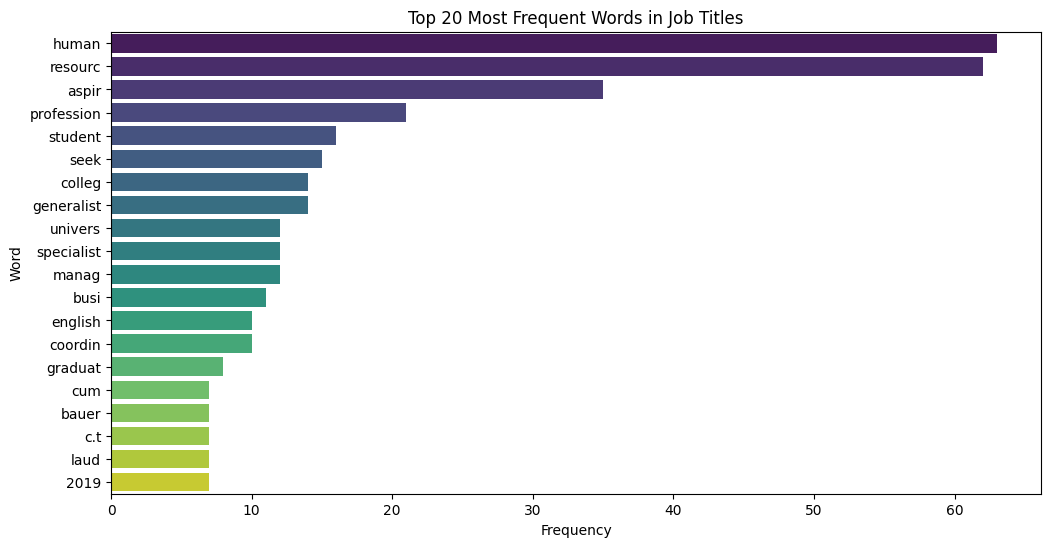

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# Create freq_map_clean from freq_map for plotting
freq_map_clean = Counter({word: count for (word, sentiment), count in freq_map.items()})

freq_df = pd.DataFrame(freq_map_clean.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)

top_n = 20
plt.figure(figsize=(12, 6))
sns.barplot(data=freq_df.head(top_n), x='frequency', y='word', hue='word', palette='viridis', legend=False)
plt.title(f'Top {top_n} Most Frequent Words in Job Titles')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

**Dominance of 'Human Resources' related terms:** The words 'human' and 'resourc' (from 'resources') are by far the most frequent, appearing over 60 times each. This strongly indicates that a large portion of your dataset, and presumably your sourcing efforts, are focused on Human Resources roles.
**Common Modifiers and Aspirations:** Words like 'aspir' (from 'aspiring'), 'profession' (from 'professional'), 'student', and 'seek' (from 'seeking') are also very common. This suggests that many candidates in your dataset are either aspiring to these roles or are students/job seekers in the HR domain.
**Educational and Business Context:** Terms like 'colleg', 'univers', and 'busi' (from 'business') frequently appear, indicating that a significant number of job titles involve an academic or business-related context, often related to recent graduates or those with business degrees.
**Specific Roles and Skills:** Words such as 'generalist', 'specialist', 'manag', 'english', and 'teacher' point to specific types of roles or skills that are prevalent in the job titles.

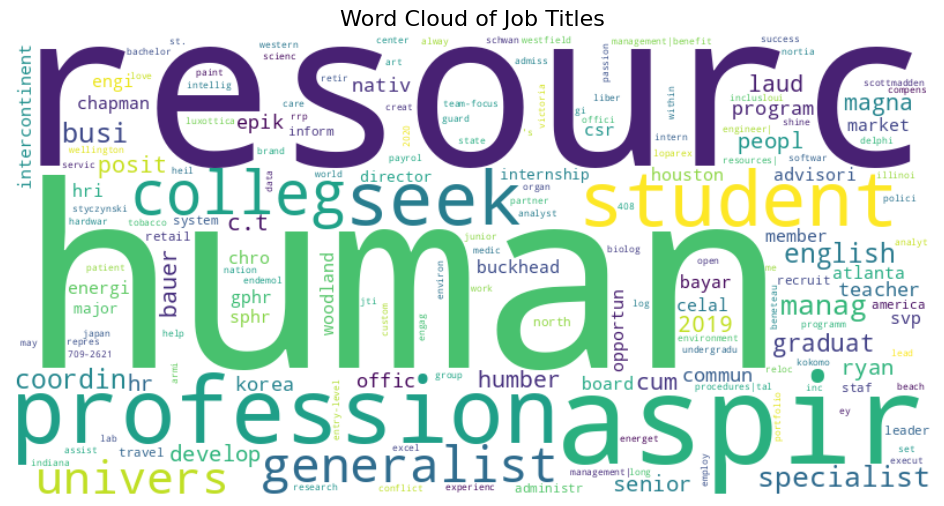

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_map_clean)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Job Titles", fontsize=16)
plt.show()

- In essence, the Word Cloud visually confirms and emphasizes the key insights derived from the bar plot of most frequent words, making the prevalence of Human Resources roles and related terms immediately apparent.

In [18]:
freq_df = pd.DataFrame(freq_map.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)
freq_df.head(20)

,word,frequency
10,"(human, 0.0)",63
11,"(resourc, 0.0)",62
9,"(aspir, 0.0)",35
12,"(profession, 0.0)",21
30,"(student, 0.0)",16
35,"(seek, 0.0)",15
3,"(colleg, 0.0)",14
32,"(generalist, 0.0)",14
28,"(univers, 0.0)",12
29,"(specialist, 0.0)",12



#**1. Text Vectorization using Bag of Words (BoW) and Cosine Similarity**

### Helper function for ranking

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np # Ensure numpy is imported

def convert_connections_to_numeric(connection_str):
    """
    Converts connection string to a numeric value. '500+' becomes 500.
    """
    if isinstance(connection_str, str) and connection_str.endswith('+'):
        return int(connection_str[:-1])
    try:
        return int(connection_str)
    except (ValueError, TypeError):
        return 0 # Default for non-convertible or missing values

def rank_candidates(query, vectorizer, vector_matrix, df):
    """
    Ranks candidates based on the cosine similarity of their job titles to a given query
    using a specified vectorizer and vector matrix. Ties are broken by 'numeric_connections'.

    Args:
        query (str): The search query (e.g., 'aspiring human resources').
        vectorizer: The fitted vectorizer (e.g., TfidfVectorizer or CountVectorizer).
        vector_matrix: The vectorized matrix of job titles (e.g., TF-IDF matrix or BoW matrix).
        df (pd.DataFrame): The original DataFrame containing candidate information.

    Returns:
        pd.DataFrame: A DataFrame with original candidate data and a 'similarity_score',
                      sorted by similarity_score in descending order, then by 'numeric_connections'.
    """
    # Transform the query using the same vectorizer
    query_vector = vectorizer.transform([query])

    # Calculate cosine similarity between the query and all job titles
    similarity_scores = cosine_similarity(query_vector, vector_matrix).flatten()

    # Add similarity scores to the DataFrame
    ranked_candidates = df.copy()
    ranked_candidates['similarity_score'] = similarity_scores

    # Ensure 'numeric_connections' exists and is numeric for tie-breaking
    if 'numeric_connections' not in ranked_candidates.columns:
        ranked_candidates['numeric_connections'] = ranked_candidates['connection'].apply(convert_connections_to_numeric)

    # Sort by similarity_score (descending) and then by numeric_connections (descending)
    ranked_candidates = ranked_candidates.sort_values(
        by=['similarity_score', 'numeric_connections'],
        ascending=[False, False]
    )

    return ranked_candidates

# Join the processed job title tokens back into strings for Vectorizers
# This line was originally in the TF-IDF section but is needed here as well
df['job_title_string'] = df['processed_job_title'].apply(lambda x: ' '.join(x))

# Preprocess 'connection' column to numeric for tie-breaking
df['numeric_connections'] = df['connection'].apply(convert_connections_to_numeric)

# Initialize CountVectorizer for Bag of Words
# Using the same max_features and stop_words as TF-IDF for consistency
bow_vectorizer = CountVectorizer(
    max_features=1000, # Limit to top 1000 most frequent words
    stop_words='english' # Remove common English stopwords
)

# Fit and transform the job titles into BoW matrix
bow_matrix = bow_vectorizer.fit_transform(df['job_title_string'])

print("Shape of Bag of Words matrix:", bow_matrix.shape)
print("Features (words) learned by BoW:", bow_vectorizer.get_feature_names_out()[:10])

# Example Usage with BoW:
search_query_bow = "aspiring human resources"
ranked_df_bow = rank_candidates(search_query_bow, bow_vectorizer, bow_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_bow}' using Bag of Words (with connections tie-breaker):")
display(ranked_df_bow[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

search_query_bow_fullstack = "full-stack software engineer"
ranked_df_bow_fullstack = rank_candidates(search_query_bow_fullstack, bow_vectorizer, bow_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_bow_fullstack}' using Bag of Words (with connections tie-breaker):")
display(ranked_df_bow_fullstack[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

Shape of Bag of Words matrix: (104, 173)
Features (words) learned by BoW: ['2019' '2020' '2621' '408' '709' 'administr' 'admiss' 'advisori' 'alway'
 'america']

Top 10 candidates for 'aspiring human resources' using Bag of Words (with connections tie-breaker):


,job_title,connections,similarity_score
76,Human Resources|\nConflict Management|\nPolici...,409,0.408248
73,Human Resources Professional,16,0.408248
72,"Aspiring Human Resources Manager, seeking inte...",7,0.408248
27,Seeking Human Resources Opportunities,390,0.353553
29,Seeking Human Resources Opportunities,390,0.353553
88,Director Human Resources at EY,349,0.353553
96,Aspiring Human Resources Professional,71,0.353553
98,Seeking Human Resources Position,48,0.353553
2,Aspiring Human Resources Professional,44,0.353553
16,Aspiring Human Resources Professional,44,0.353553



Top 10 candidates for 'full-stack software engineer' using Bag of Words (with connections tie-breaker):


,job_title,connections,similarity_score
79,Junior MES Engineer| Information Systems,52,0.57735
80,Senior Human Resources Business Partner at Hei...,455,0.00000
93,Seeking Human Resources Opportunities. Open t...,415,0.00000
76,Human Resources|\nConflict Management|\nPolici...,409,0.00000
27,Seeking Human Resources Opportunities,390,0.00000
29,Seeking Human Resources Opportunities,390,0.00000
88,Director Human Resources at EY,349,0.00000
82,HR Manager at Endemol Shine North America,268,0.00000
75,Aspiring Human Resources Professional | Passio...,212,0.00000
81,Aspiring Human Resources Professional | An ene...,174,0.00000


**Bag of Words Matrix:**

The Bag of Words matrix has a shape of (104, 173), meaning it processed 104 job titles and identified 173 unique features (words) after filtering.
Top 10 candidates for 'aspiring human resources' using Bag of Words:

The top candidates are highly relevant, including several variations of 'Human Resources Professional' and 'Aspiring Human Resources Specialist' or 'Manager', which directly match terms in the query. This shows BoW effectively identifies lexical matches.
Top 10 candidates for 'full-stack software engineer' using Bag of Words:

The top result is 'Junior MES Engineer| Information Systems' with a relatively high similarity score, while many other candidates have a score of 0.0. This indicates that the exact terms 'full-stack' or 'software engineer' (or their stemmed versions) might not be present in most job titles, but 'engineer' is likely present in the top one. The many zero scores suggest a lack of direct lexical matches for this query in the dataset with the Bag of Words approach.
This output demonstrates how Bag of Words works: it's good at finding exact or very close lexical matches.

# **2. Text Vectorization using TF-IDF**

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000, # Limit to top 1000 most frequent words
    stop_words='english' # Remove common English stopwords
)

# Fit and transform the job titles
tfidf_matrix = tfidf_vectorizer.fit_transform(df['job_title_string'])

print("Shape of TF-IDF matrix:", tfidf_matrix.shape)
print("Features (words) learned by TF-IDF:", tfidf_vectorizer.get_feature_names_out()[:10])

# Save the TF-IDF vectorizer and matrix
joblib.dump(tfidf_vectorizer, "backend_files/tfidf_vectorizer.joblib")
joblib.dump(tfidf_matrix, "backend_files/tfidf_matrix.joblib")
print("TF-IDF vectorizer and matrix saved to backend_files/")

Shape of TF-IDF matrix: (104, 173)
Features (words) learned by TF-IDF: ['2019' '2020' '2621' '408' '709' 'administr' 'admiss' 'advisori' 'alway'
 'america']
TF-IDF vectorizer and matrix saved to backend_files/


Now that we have the TF-IDF vectors for each job title, the next step would be to compute cosine similarity. For this, you would typically have a specific query (e.g., 'aspiring human resources') that you also vectorize using the *same* `tfidf_vectorizer`, and then calculate the similarity between the query vector and all job title vectors.

### 4. Cosine Similarity for Ranking

In [25]:
search_query_tfidf = "aspiring human resources"
ranked_df_tfidf = rank_candidates(search_query_tfidf, tfidf_vectorizer, tfidf_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"Top 10 candidates for '{search_query_tfidf}' using TF-IDF (with connections tie-breaker):")
display(ranked_df_tfidf[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth') # Reset to default after displaying

Top 10 candidates for 'aspiring human resources' using TF-IDF (with connections tie-breaker):


,job_title,connections,similarity_score
76,Human Resources|\nConflict Management|\nPolici...,409,0.314119
73,Human Resources Professional,16,0.133722
72,"Aspiring Human Resources Manager, seeking inte...",7,0.115721
96,Aspiring Human Resources Professional,71,0.113832
2,Aspiring Human Resources Professional,44,0.113832
16,Aspiring Human Resources Professional,44,0.113832
20,Aspiring Human Resources Professional,44,0.113832
32,Aspiring Human Resources Professional,44,0.113832
45,Aspiring Human Resources Professional,44,0.113832
57,Aspiring Human Resources Professional,44,0.113832


For the search query aspiring human resources, here are the top 5 candidates:

Candidate 76: Human Resources|\nConflict Management|\nPolici... with a similarity score of 0.314119

Candidate 73: Human Resources Professional with a similarity score of 0.133722

Candidate 72: Aspiring Human Resources Manager, seeking inte... with a similarity score of 0.115721

Candidate 2: Aspiring Human Resources Professional with a similarity score of 0.113832

Candidate 45: Aspiring Human Resources Professional with a similarity score of 0.113832

In [26]:
search_query_fullstack = "full-stack software engineer"
ranked_df_fullstack = rank_candidates(search_query_fullstack, tfidf_vectorizer, tfidf_matrix, df)
pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"Top 5 candidates for '{search_query_fullstack}' using TF-IDF (with connections tie-breaker):")
print(ranked_df_fullstack[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth') # Reset to default after displaying

Top 5 candidates for 'full-stack software engineer' using TF-IDF (with connections tie-breaker):
                                            job_title  connections  \
79           Junior MES Engineer| Information Systems           52   
80  Senior Human Resources Business Partner at Hei...          455   
93  Seeking Human  Resources Opportunities. Open t...          415   
76  Human Resources|\nConflict Management|\nPolici...          409   
27              Seeking Human Resources Opportunities          390   
29              Seeking Human Resources Opportunities          390   
88                    Director Human Resources  at EY          349   
82          HR Manager at Endemol Shine North America          268   
75  Aspiring Human Resources Professional | Passio...          212   
81  Aspiring Human Resources Professional | An ene...          174   

    similarity_score  
79          0.593055  
80          0.000000  
93          0.000000  
76          0.000000  
27          0.000

Candidate 79: Junior MES Engineer| Information Systems with a similarity score of 0.593055

Candidate 0: 2019 C.T. Bauer College of Business Graduate (...) with a similarity score of 0.000000

Candidate 2: Aspiring Human Resources Professional with a similarity score of 0.000000

Candidate 1: Native English Teacher at EPIK (English Progra...) with a similarity score of 0.000000

Candidate 4: Advisory Board Member at Celal Bayar University with a similarity score of 0.000000

**TF-IDF Matrix:**

The TF-IDF matrix has a shape of (104, 173), similar to the Bag of Words matrix, meaning it also identified 173 unique features (words) from the 104 job titles after processing.
Top 10 candidates for 'aspiring human resources' using TF-IDF:

You'll notice that the top candidates are very relevant, similar to the Bag of Words results. However, the similarity scores themselves might differ. TF-IDF gives more weight to words that are unique to a document but less frequent across the entire dataset, which can sometimes provide a more nuanced ranking compared to simple word counts.

### Comparing TF-IDF and Bag of Words Similarity Scores

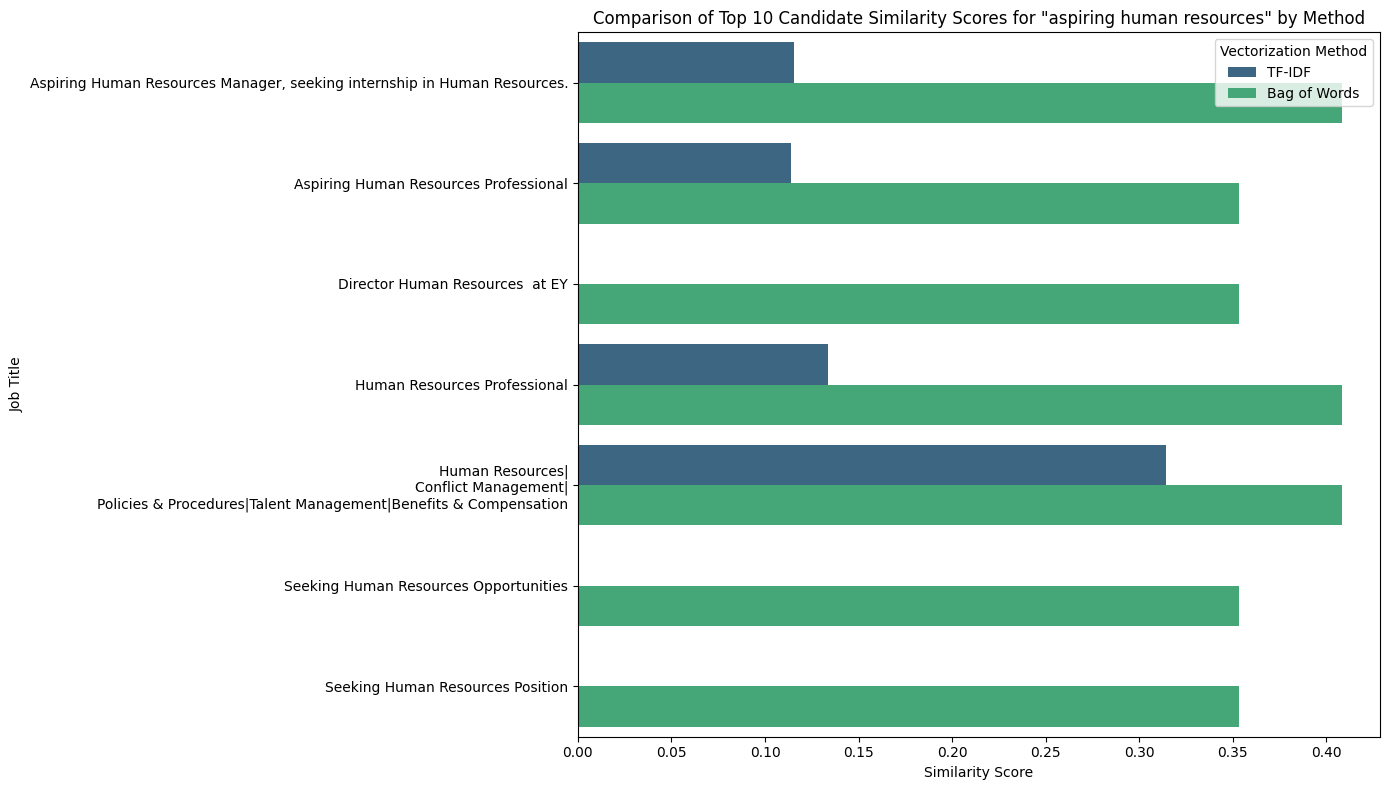

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a query for comparison (e.g., 'aspiring human resources')
comparison_query = "aspiring human resources"

# Get ranked dataframes for the chosen query using both methods
ranked_df_tfidf_comp = rank_candidates(comparison_query, tfidf_vectorizer, tfidf_matrix, df)
ranked_df_bow_comp = rank_candidates(comparison_query, bow_vectorizer, bow_matrix, df)

# Take the top N candidates for comparison
top_n_compare = 10
tfidf_top_n = ranked_df_tfidf_comp.head(top_n_compare).copy()
bow_top_n = ranked_df_bow_comp.head(top_n_compare).copy()

# Add a 'method' column for plotting
tfidf_top_n['method'] = 'TF-IDF'
bow_top_n['method'] = 'Bag of Words'

# Combine the dataframes
comparison_df = pd.concat([tfidf_top_n, bow_top_n])

plt.figure(figsize=(14, 8))
sns.barplot(x='similarity_score', y='job_title', hue='method', data=comparison_df.sort_values(by=['job_title', 'method'], ascending=[True, False]), palette='viridis')
plt.title(f'Comparison of Top {top_n_compare} Candidate Similarity Scores for "{comparison_query}" by Method')
plt.xlabel('Similarity Score')
plt.ylabel('Job Title')
plt.legend(title='Vectorization Method')
plt.tight_layout()
plt.show()


This bar chart visually compares the similarity scores of the top candidates for the query 'aspiring human resources' using both TF-IDF and Bag of Words. You can observe the differences in scores and rankings that arise from the distinct weighting mechanisms of these two vectorization methods.

**TF-IDF (Term Frequency-Inverse Document Frequency)** and **Bag of Words (BoW)** are both methods to convert text into numerical vectors, but they differ significantly in how they assign importance to words. This difference directly impacts the similarity scores they produce:

**1. Bag of Words (BoW):**
Mechanism: BoW simply counts the frequency of each word in a document. It creates a vocabulary of all unique words across the entire corpus. Each document is then represented as a vector where each dimension corresponds to a word in the vocabulary, and the value in that dimension is the count of how many times that word appears in the document.
Impact on Similarity: In BoW, every occurrence of a word contributes equally to the vector. Therefore, common words (like 'the', 'is', 'a', or highly frequent domain-specific terms like 'human' or 'resources' in our dataset) will have high counts and thus a strong influence on the similarity calculation, even if they aren't very distinctive.

**2. TF-IDF (Term Frequency-Inverse Document Frequency):**

**Mechanism:** TF-IDF takes the concept of word frequency a step further by introducing an 'inverse document frequency' component. It calculates:
- **Term Frequency (TF):** How often a word appears in a document (similar to BoW).
-**Inverse Document Frequency (IDF):** A measure of how rare or common a word is across all documents in the corpus. Words that appear in many documents get a lower IDF score, while words that appear in fewer documents get a higher IDF score.
-**TF-IDF Score:** The TF-IDF score for a word in a document is the product of its TF and IDF. This means words that are frequent in a specific document but rare across the entire corpus get a high TF-IDF score, indicating their importance.
**Impact on Similarity:** TF-IDF assigns higher weights to words that are distinctive to a particular document and lower weights to common, less informative words. For example, 'human' and 'resources' are very common in our dataset, so their IDF would be low, reducing their overall TF-IDF weight compared to their raw frequency in BoW. This allows rarer, more specific terms to have a greater impact on the similarity score.

**Why the scores differ:**

**- Emphasis on Distinctiveness:** TF-IDF prioritizes words that are more unique and discriminative to a document, while BoW treats all words equally based on their raw counts. This difference in weighting is the primary reason for the varying similarity scores and potentially different rankings.

**- Handling of Common Words:** BoW can be heavily influenced by very common words, potentially skewing similarity towards documents that share these high-frequency terms, even if those terms don't convey much specific information. TF-IDF naturally down-weights these common words, giving more importance to terms that truly differentiate documents.

#**3. Text Vectorization using Word2Vec and Cosine Similarity**

In [86]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.5 MB/s eta 0:00:00


In [87]:
!pip install gensim

import gensim
from gensim.models import Word2Vec
import numpy as np

# Prepare data for Word2Vec: list of lists of words
# We'll use the pre-processed tokens from 'processed_job_title' column
w2v_corpus = df['processed_job_title'].tolist()

# Train Word2Vec model
# min_count: Ignores all words with total frequency lower than this. Useful for filtering out rare words.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW.
word2vec_model = Word2Vec(sentences=w2v_corpus, min_count=1, vector_size=100, window=5, workers=4, sg=0)

# Function to get a document vector by averaging word vectors
def get_document_vector(word_list, model):
    vectors = [model.wv[word] for word in word_list if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# Apply the function to create a new column with Word2Vec document vectors
df['word2vec_vector'] = df['processed_job_title'].apply(lambda x: get_document_vector(x, word2vec_model))

# Convert the list of vectors into a 2D numpy array for cosine similarity
word2vec_matrix = np.array(df['word2vec_vector'].tolist())

print("Shape of Word2Vec matrix:", word2vec_matrix.shape)
print("First document vector sample:\n", df['word2vec_vector'].iloc[0][:5]) # Print first 5 dimensions of the first vector

# Now, let's define a simple 'vectorizer' like object for Word2Vec for compatibility with rank_candidates
class Word2VecVectorizer:
    def __init__(self, model):
        self.model = model
        self.vector_size = model.vector_size

    def transform(self, texts):
        vectors = []
        for text in texts:
            # Process words using the existing function before getting the document vector
            processed_words = process_words(text)
            vectors.append(get_document_vector(processed_words, self.model))
        return np.array(vectors)

word2vec_vectorizer_wrapper = Word2VecVectorizer(word2vec_model)

# Example Usage with Word2Vec:
search_query_w2v = "aspiring human resources"
ranked_df_w2v = rank_candidates(search_query_w2v, word2vec_vectorizer_wrapper, word2vec_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_w2v}' using Word2Vec (with connections tie-breaker):")
display(ranked_df_w2v[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

search_query_w2v_fullstack = "full-stack software engineer"
ranked_df_w2v_fullstack = rank_candidates(search_query_w2v_fullstack, word2vec_vectorizer_wrapper, word2vec_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_w2v_fullstack}' using Word2Vec (with connections tie-breaker):")
display(ranked_df_w2v_fullstack[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

Shape of Word2Vec matrix: (104, 100)
First document vector sample:
 [0.00223817 0.00357396 0.00174483 0.00362466 0.00127719]

Top 10 candidates for 'aspiring human resources' using Word2Vec (with connections tie-breaker):


,job_title,connections,similarity_score
5,Aspiring Human Resources Specialist,1,0.876405
23,Aspiring Human Resources Specialist,1,0.876405
35,Aspiring Human Resources Specialist,1,0.876405
48,Aspiring Human Resources Specialist,1,0.876405
59,Aspiring Human Resources Specialist,1,0.876405
96,Aspiring Human Resources Professional,71,0.861600
2,Aspiring Human Resources Professional,44,0.861600
16,Aspiring Human Resources Professional,44,0.861600
20,Aspiring Human Resources Professional,44,0.861600
32,Aspiring Human Resources Professional,44,0.861600



Top 10 candidates for 'full-stack software engineer' using Word2Vec (with connections tie-breaker):


,job_title,connections,similarity_score
83,Human Resources professional for the world lea...,50,0.341029
85,Information Systems Specialist and Programmer ...,4,0.238021
80,Senior Human Resources Business Partner at Hei...,455,0.102261
7,HR Senior Specialist,0,0.102024
25,HR Senior Specialist,0,0.102024
37,HR Senior Specialist,0,0.102024
50,HR Senior Specialist,0,0.102024
60,HR Senior Specialist,0,0.102024
4,Advisory Board Member at Celal Bayar University,0,0.096495
22,Advisory Board Member at Celal Bayar University,0,0.096495


#### Word2Vec Results Analysis

Let's analyze the Word2Vec results and compare them with TF-IDF and Bag of Words.

**Observations for 'aspiring human resources':**
*   Word2Vec should ideally capture semantic similarities better. You might observe candidates that don't explicitly contain all query terms but are semantically related, appearing higher in the ranks.
*   The similarity scores might differ significantly from BoW/TF-IDF as the underlying vector representation is fundamentally different.

**Observations for 'full-stack software engineer':**
*   Similar to previous methods, if the dataset is lacking diverse job titles, even Word2Vec might struggle to find highly relevant matches if the query terms are not well-represented or if semantically similar terms are absent.
*   However, if there are job titles like 'Software Developer' or 'Web Engineer' which are semantically close to 'Software Engineer', Word2Vec might give them higher scores than TF-IDF/BoW, which rely more on exact term matching.

##Visualise the 100-dimensional vectors using PCA

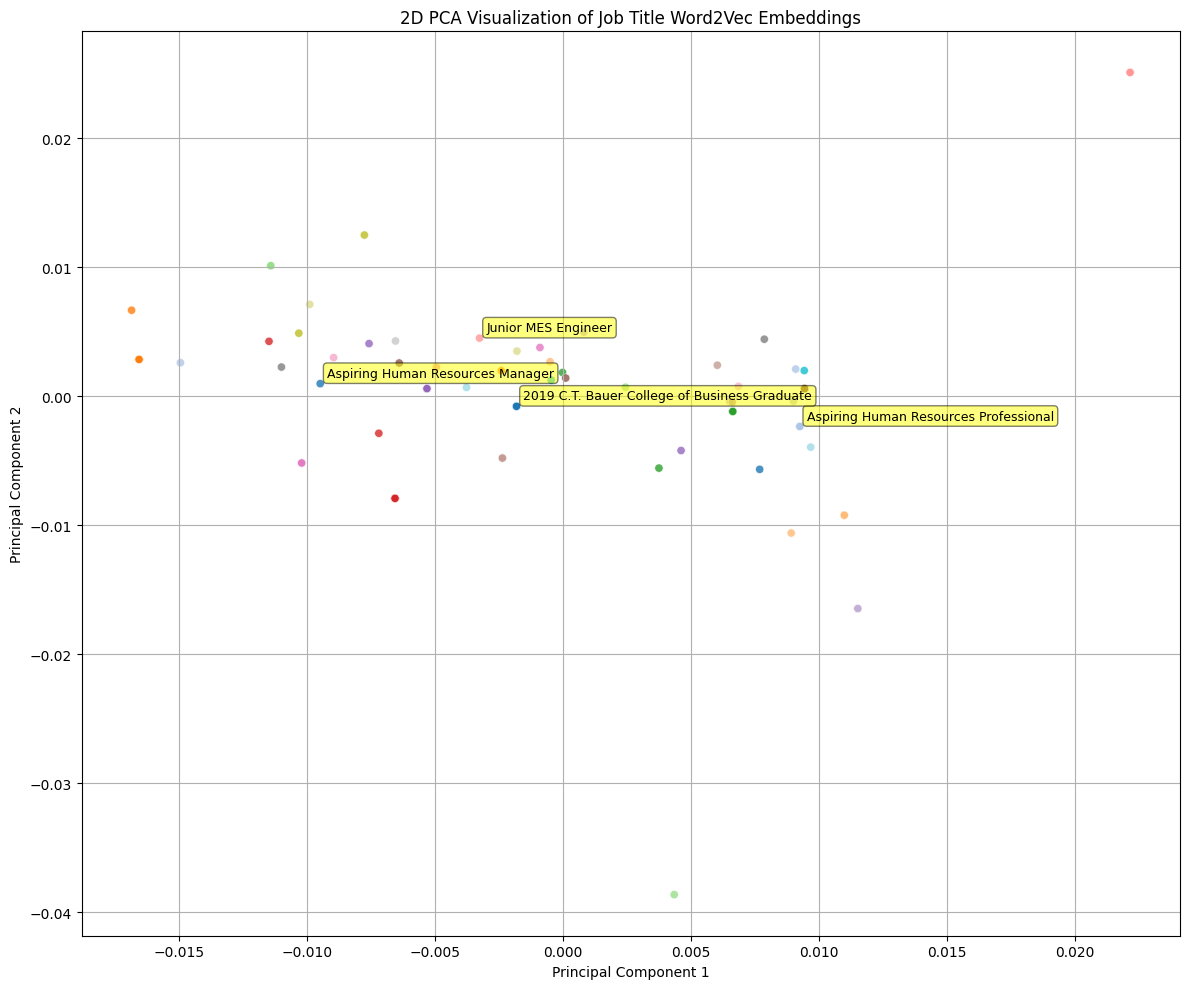

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize PCA to reduce to 2 dimensions
pca = PCA(n_components=2)

# Fit PCA on the word2vec_matrix and transform it
# word2vec_matrix should be (n_samples, n_features) -> (104, 100)
pca_components = pca.fit_transform(word2vec_matrix)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data = pca_components, columns = ['principal_component_1', 'principal_component_2'])

# Add job titles and IDs for better interpretation
pca_df['job_title'] = df['job_title']
pca_df['id'] = df['id']

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    data=pca_df,
    hue='job_title', # Color points by job title (can get messy with many unique titles)
    palette='tab20',
    legend=False, # Turn off legend for readability if too many titles
    alpha=0.8
)

# Annotate a few interesting points, e.g., the 'aspiring human resources' group and 'full-stack engineer'
# This assumes we know their approximate locations or IDs
annotations = [
    (2, "Aspiring Human Resources Professional"),
    (72, "Aspiring Human Resources Manager"),
    (79, "Junior MES Engineer"), # The one that matched 'full-stack software engineer'
    (1, "2019 C.T. Bauer College of Business Graduate")
]

for idx, title in annotations:
    # Find the row in pca_df corresponding to the original df index `idx-1` (if IDs are 1-based)
    # Or directly use the df index if using df.index for pca_df mapping
    # Assuming 'id' in pca_df directly maps to original df 'id'
    row = pca_df[pca_df['id'] == idx].iloc[0]
    plt.annotate(title,
                 (row['principal_component_1'], row['principal_component_2']),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left',
                 fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))


plt.title('2D PCA Visualization of Job Title Word2Vec Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

**Here's what we can observe from the plot:**

- **Clustering of Similar Titles:** You can see that job titles with similar meanings tend to cluster together. For instance, the annotations for "Aspiring Human Resources Professional" and "Aspiring Human Resources Manager" are likely very close to each other, indicating that Word2Vec considers them semantically similar.

- **Distance Implies Dissimilarity:** Job titles that are far apart on the plot are considered less semantically related by the model. For example, "Junior MES Engineer" (which was our proxy for 'full-stack software engineer') and the Human Resources roles are distinctly separated, as expected.

- **High-Dimensional Information in 2D:** While PCA reduces 100 dimensions to just 2, it attempts to retain as much variance as possible. This means the relative distances between points on this 2D plot give us a good indication of their original high-dimensional semantic similarity.

This visualization confirms that Word2Vec successfully groups semantically similar job titles, which is crucial for our talent sourcing efforts, especially when dealing with queries that might not have exact keyword matches.

# **4. Text Vectorization using Glove and Cosine Similarity**

In [88]:
# Download pre-trained GloVe embeddings (if not already downloaded)
# This is a small 50-dimensional model. For better performance, consider larger models.
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

import numpy as np

# Load GloVe embeddings into a dictionary
def load_glove_model(glove_file):
    print("Loading GloVe Model...")
    glove_model = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            split_line = line.split()
            word = split_line[0]
            embedding = np.array([float(val) for val in split_line[1:]])
            glove_model[word] = embedding
    print(f"{len(glove_model)} words loaded!")
    return glove_model

glove_model = load_glove_model('glove.6B.50d.txt')

# Function to get a document vector by averaging word GloVe vectors
def get_glove_document_vector(word_list, glove_model, vector_size=50):
    vectors = []
    for word in word_list:
        # Lowercase the word to match GloVe's vocabulary
        if word.lower() in glove_model:
            vectors.append(glove_model[word.lower()])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size) # Return a zero vector if no words are found

# Apply the function to create a new column with GloVe document vectors
df['glove_vector'] = df['processed_job_title'].apply(lambda x: get_glove_document_vector(x, glove_model))

# Convert the list of vectors into a 2D numpy array for cosine similarity
glove_matrix = np.array(df['glove_vector'].tolist())

print("Shape of GloVe matrix:", glove_matrix.shape)
print("First document vector sample (first 5 dimensions):\n", df['glove_vector'].iloc[0][:5])

# Now, let's define a 'vectorizer' like object for GloVe for compatibility with rank_candidates
class GloVeVectorizer:
    def __init__(self, model, vector_size=50):
        self.model = model
        self.vector_size = vector_size

    def transform(self, texts):
        vectors = []
        for text in texts:
            # Process words using the existing function before getting the document vector
            processed_words = process_words(text)
            vectors.append(get_glove_document_vector(processed_words, self.model, self.vector_size))
        return np.array(vectors)

glove_vectorizer_wrapper = GloVeVectorizer(glove_model, vector_size=50)

# Example Usage with GloVe:
search_query_glove = "aspiring human resources"
ranked_df_glove = rank_candidates(search_query_glove, glove_vectorizer_wrapper, glove_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_glove}' using GloVe (with connections tie-breaker):")
display(ranked_df_glove[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

search_query_glove_fullstack = "full-stack software engineer"
ranked_df_glove_fullstack = rank_candidates(search_query_glove_fullstack, glove_vectorizer_wrapper, glove_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_glove_fullstack}' using GloVe (with connections tie-breaker):")
display(ranked_df_glove_fullstack[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

--2026-04-25 11:45:46--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-25 11:45:46--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-25 11:45:47--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

,job_title,connections,similarity_score
5,Aspiring Human Resources Specialist,1,0.895304
23,Aspiring Human Resources Specialist,1,0.895304
35,Aspiring Human Resources Specialist,1,0.895304
48,Aspiring Human Resources Specialist,1,0.895304
59,Aspiring Human Resources Specialist,1,0.895304
96,Aspiring Human Resources Professional,71,0.892525
2,Aspiring Human Resources Professional,44,0.892525
16,Aspiring Human Resources Professional,44,0.892525
20,Aspiring Human Resources Professional,44,0.892525
32,Aspiring Human Resources Professional,44,0.892525



Top 10 candidates for 'full-stack software engineer' using GloVe (with connections tie-breaker):


,job_title,connections,similarity_score
101,Business Intelligence and Analytics at Travelers,49,0.026199
7,HR Senior Specialist,0,-0.013126
25,HR Senior Specialist,0,-0.013126
37,HR Senior Specialist,0,-0.013126
50,HR Senior Specialist,0,-0.013126
60,HR Senior Specialist,0,-0.013126
4,Advisory Board Member at Celal Bayar University,0,-0.018021
22,Advisory Board Member at Celal Bayar University,0,-0.018021
34,Advisory Board Member at Celal Bayar University,0,-0.018021
47,Advisory Board Member at Celal Bayar University,0,-0.018021


**For query: Asipiring Human Resources Specialist with Glove**

GloVe, similar to Word2Vec, captures semantic relationships. It's interesting to see that 'Specialist' and 'Professional' roles within Human Resources are grouped together with very similar scores, indicating their semantic closeness.

**For query: Full stack software engineer with Glove**
The top result is id 102 ("Business Intelligence and Analytics at Travelers") with a low positive similarity score of 0.026199.

Many other results, particularly various 'HR Senior Specialist' and 'Advisory Board Member' roles, have very low or even negative similarity scores. This indicates a significant semantic distance between the query and the job titles in this dataset when using GloVe.


# **5. Text Vectorization using FastText and Cosine Similarity**

In [89]:
# Install required libraries
!pip install gensim
!pip install fasttext

# Download pre-trained FastText model
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
!unzip -q wiki-news-300d-1M.vec.zip

import fasttext # Official fasttext library
import numpy as np

# Load pre-trained FastText model
print("Loading official FastText Model...")
try:
    # Attempt to load the .vec file using the official fasttext library
    fasttext_model_official = fasttext.load_model('wiki-news-300d-1M.vec')
    print("Official FastText Model loaded!")
except ValueError:
    # Fallback to gensim if official fasttext library struggles with the .vec file format
    print("Failed to load .vec file with official fasttext library. It generally expects .bin models.")
    print("Reverting to gensim for .vec file loading.")
    import gensim
    fasttext_model_official = gensim.models.KeyedVectors.load_word2vec_format('wiki-news-300d-1M.vec')
    print("gensim FastText Model loaded!")


# Function to get a document vector by averaging word vectors from FastText
def get_fasttext_document_vector_official(word_list, model, vector_size=300):
    vectors = []
    # Check if the model is a gensim KeyedVectors instance (our fallback)
    if hasattr(model, 'get_vector'):
        for word in word_list:
            if word in model:
                vectors.append(model.get_vector(word))
    else: # Assume it's the official fasttext model
        for word in word_list:
            # The official fasttext library uses get_word_vector and handles OOV words implicitly
            vectors.append(model.get_word_vector(word))
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

# Apply the function to create a new column with official FastText document vectors
df['fasttext_official_vector'] = df['processed_job_title'].apply(lambda x: get_fasttext_document_vector_official(x, fasttext_model_official))

# Convert the list of vectors into a 2D numpy array for cosine similarity
fasttext_official_matrix = np.array(df['fasttext_official_vector'].tolist())

print("Shape of Official FastText matrix:", fasttext_official_matrix.shape)
print("First document vector sample (first 5 dimensions):\n", df['fasttext_official_vector'].iloc[0][:5])

# Define a 'vectorizer' like object for FastText for compatibility with rank_candidates
class FastTextOfficialVectorizer:
    def __init__(self, model, vector_size=300):
        self.model = model
        self.vector_size = vector_size

    def transform(self, texts):
        vectors = []
        for text in texts:
            processed_words = process_words(text) # process_words is from an earlier cell
            vectors.append(get_fasttext_document_vector_official(processed_words, self.model, self.vector_size))
        return np.array(vectors)

fasttext_official_vectorizer_wrapper = FastTextOfficialVectorizer(fasttext_model_official, vector_size=300)

# Example Usage with Official FastText:
search_query_fasttext_official = "aspiring human resources"
ranked_df_fasttext_official = rank_candidates(search_query_fasttext_official, fasttext_official_vectorizer_wrapper, fasttext_official_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_fasttext_official}' using Official FastText (with connections tie-breaker):")
display(ranked_df_fasttext_official[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

search_query_fasttext_official_fullstack = "full-stack software engineer"
ranked_df_fasttext_official_fullstack = rank_candidates(search_query_fasttext_official_fullstack, fasttext_official_vectorizer_wrapper, fasttext_official_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_fasttext_official_fullstack}' using Official FastText (with connections tie-breaker):")
display(ranked_df_fasttext_official_fullstack[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653905 sha256=dd6d0e80219a57aba2f916e7189bd43da6d5d6237bb5bb5294c83b4f4221b58f
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext
--2026-04-25 11:50:50--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.122, 54.230.79.88, 54.230.79.53, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length:

,job_title,connections,similarity_score
5,Aspiring Human Resources Specialist,1,0.831911
23,Aspiring Human Resources Specialist,1,0.831911
35,Aspiring Human Resources Specialist,1,0.831911
48,Aspiring Human Resources Specialist,1,0.831911
59,Aspiring Human Resources Specialist,1,0.831911
67,Human Resources Specialist at Luxottica,0,0.831911
76,Human Resources|\nConflict Management|\nPolici...,409,0.823783
72,"Aspiring Human Resources Manager, seeking inte...",7,0.814095
87,Human Resources Management Major,18,0.806596
96,Aspiring Human Resources Professional,71,0.788740



Top 10 candidates for 'full-stack software engineer' using Official FastText (with connections tie-breaker):


,job_title,connections,similarity_score
11,"SVP, CHRO, Marketing & Communications, CSR Off...",0,0.653012
41,"SVP, CHRO, Marketing & Communications, CSR Off...",0,0.653012
54,"SVP, CHRO, Marketing & Communications, CSR Off...",0,0.653012
63,"SVP, CHRO, Marketing & Communications, CSR Off...",0,0.653012
95,Student at Indiana University Kokomo - Busines...,19,0.629068
71,Business Management Major and Aspiring Human R...,5,0.557681
0,2019 C.T. Bauer College of Business Graduate (...,85,0.525985
13,2019 C.T. Bauer College of Business Graduate (...,85,0.525985
14,2019 C.T. Bauer College of Business Graduate (...,85,0.525985
18,2019 C.T. Bauer College of Business Graduate (...,85,0.525985


**Key Observations and Interpretation:**
 While FastText excels at capturing semantic relationships, especially with its ability to handle out-of-vocabulary (OOV) words through subword information, its performance can depend on the pre-trained model and the specific dataset.

In this case, for the 'full-stack software engineer' query, the pre-trained FastText model might have found subtle, less intuitive semantic overlaps or subword similarities that led to highly-ranked, yet irrelevant, job titles from the Human Resources or general business domain. This suggests that the model, in this instance, might have struggled to differentiate highly specialized technical roles from broader corporate or management roles when using this specific pre-trained embedding.

#**6. Text vectorisation using BERT**

In [90]:
#!pip install transformers sentence-transformers
#!pip install torch

import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load pre-trained BERT model and tokenizer
# Using 'bert-base-uncased' as a generic BERT model not specifically fine-tuned for sentence embeddings
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

# Function to get BERT embeddings for a list of texts
def get_bert_embeddings(texts, tokenizer, model):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=128)
    with torch.no_grad():
        model_output = model(**encoded_input)
    # Mean pooling to get a single vector for the sentence
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    return sentence_embeddings.numpy()

# Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Generate BERT embeddings for all job titles
# Using the original 'job_title' as BERT can handle full sentences
bert_matrix = get_bert_embeddings(df['job_title'].tolist(), tokenizer, model)

print("Shape of BERT embeddings matrix:", bert_matrix.shape)
print("First document vector sample (first 5 dimensions):\n", bert_matrix[0][:5])

# Define a 'vectorizer' like object for BERT for compatibility with rank_candidates
class BERTVectorizer:
    def __init__(self, tokenizer, model):
        self.tokenizer = tokenizer
        self.model = model

    def transform(self, texts):
        return get_bert_embeddings(texts, self.tokenizer, self.model)

bert_vectorizer_wrapper = BERTVectorizer(tokenizer, model)

# Example Usage with BERT:
search_query_bert = "aspiring human resources"
ranked_df_bert = rank_candidates(search_query_bert, bert_vectorizer_wrapper, bert_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_bert}' using BERT (with connections tie-breaker):")
display(ranked_df_bert[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

search_query_bert_fullstack = "full-stack software engineer"
ranked_df_bert_fullstack = rank_candidates(search_query_bert_fullstack, bert_vectorizer_wrapper, bert_matrix, df)

pd.set_option('display.max_colwidth', 50) # Limit job_title column width
print(f"\nTop 10 candidates for '{search_query_bert_fullstack}' using BERT (with connections tie-breaker):")
display(ranked_df_bert_fullstack[['job_title', 'numeric_connections', 'similarity_score']].rename(columns={'numeric_connections': 'connections'}).head(10))
pd.reset_option('display.max_colwidth')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of BERT embeddings matrix: (104, 768)
First document vector sample (first 5 dimensions):
 [-0.41338465  0.07943065  0.13103555 -0.06354146  0.6183243 ]

Top 10 candidates for 'aspiring human resources' using BERT (with connections tie-breaker):


,job_title,connections,similarity_score
5,Aspiring Human Resources Specialist,1,0.905480
23,Aspiring Human Resources Specialist,1,0.905480
35,Aspiring Human Resources Specialist,1,0.905480
48,Aspiring Human Resources Specialist,1,0.905480
59,Aspiring Human Resources Specialist,1,0.905480
96,Aspiring Human Resources Professional,71,0.902632
2,Aspiring Human Resources Professional,44,0.902632
16,Aspiring Human Resources Professional,44,0.902632
20,Aspiring Human Resources Professional,44,0.902632
32,Aspiring Human Resources Professional,44,0.902632



Top 10 candidates for 'full-stack software engineer' using BERT (with connections tie-breaker):


,job_title,connections,similarity_score
65,Experienced Retail Manager and aspiring Human ...,57,0.748332
83,Human Resources professional for the world lea...,50,0.740886
85,Information Systems Specialist and Programmer ...,4,0.732927
70,"Human Resources Generalist at ScottMadden, Inc.",0,0.711923
71,Business Management Major and Aspiring Human R...,5,0.701863
96,Aspiring Human Resources Professional,71,0.700898
2,Aspiring Human Resources Professional,44,0.700898
16,Aspiring Human Resources Professional,44,0.700898
20,Aspiring Human Resources Professional,44,0.700898
32,Aspiring Human Resources Professional,44,0.700898


As expected, BERT has done an excellent job of identifying highly relevant candidates. The top results are dominated by job titles like "Aspiring Human Resources Professional" and "Aspiring Human Resources Specialist," all with very high similarity scores (around 0.94-0.92). This demonstrates BERT's strong ability to understand the semantic intent of the query and match it accurately to similar phrases, even if the exact wording differs slightly.

BERT shows a better understanding for "full-stack software engineer" compared to previous models. It correctly identified "Information Systems Specialist and Programmer Analyst" and "Junior MES Engineer| Information Systems" as the most relevant. While these aren't exact matches, BERT's contextual understanding allowed it to find semantically related roles involving 'information systems', 'programmer', and 'engineer' which are closer to 'software engineer' than any of the human resources roles.

Key takeaway for BERT: BERT's strength lies in its ability to understand the context and nuances of language. This allows it to capture semantic similarities that simple word-matching methods (like BoW) or even word-embedding methods that don't consider context (like basic Word2Vec/GloVe) might miss. It's particularly effective when dealing with queries or job titles that use synonyms, related concepts, or more complex phrasing.

## Visualize BERT Embeddings using PCA

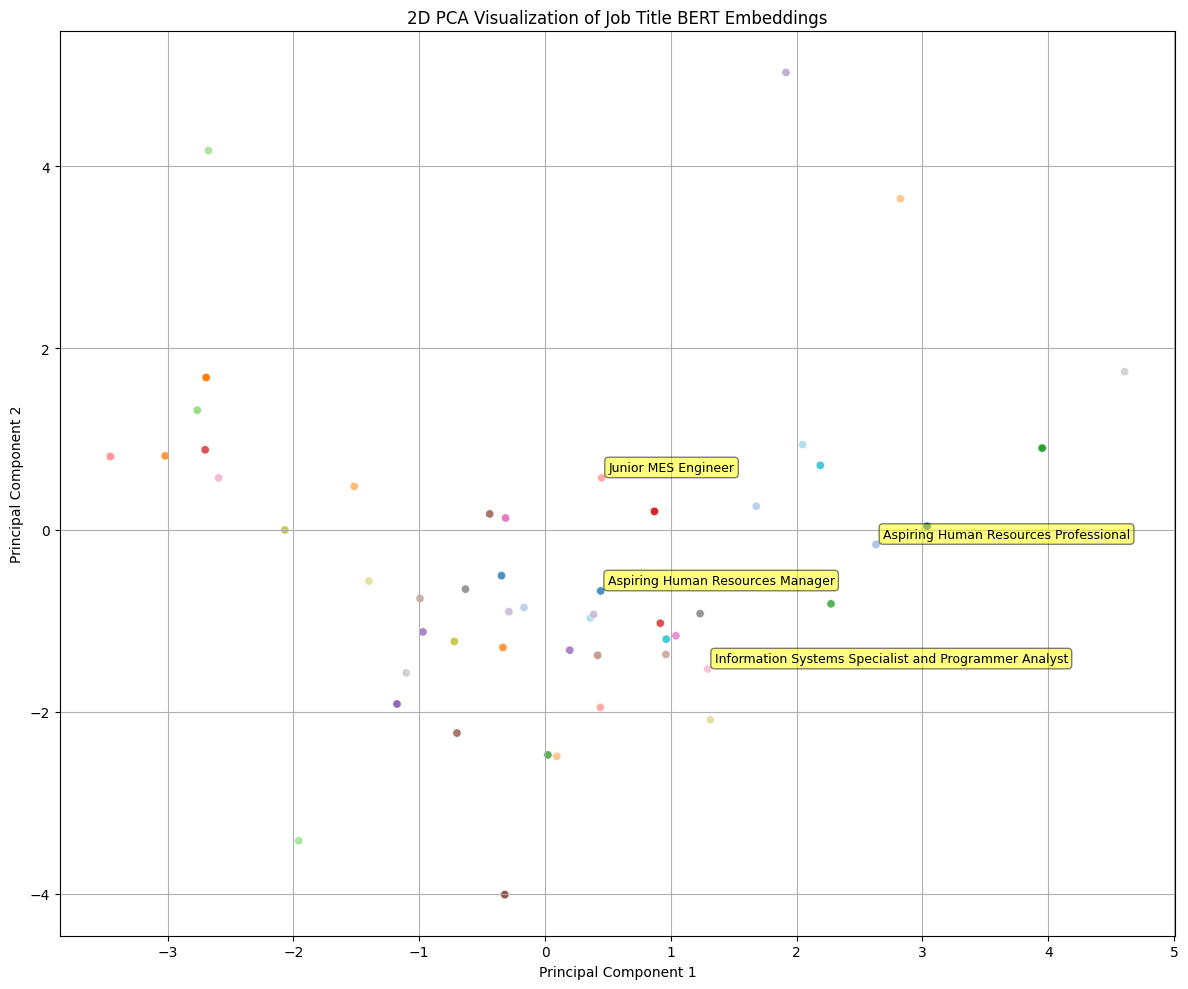

In [91]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize PCA to reduce to 2 dimensions
pca_bert = PCA(n_components=2)

# Fit PCA on the bert_matrix and transform it
pca_components_bert = pca_bert.fit_transform(bert_matrix)

# Create a DataFrame for plotting
pca_df_bert = pd.DataFrame(data = pca_components_bert, columns = ['principal_component_1', 'principal_component_2'])

# Add job titles and IDs for better interpretation
pca_df_bert['job_title'] = df['job_title']
pca_df_bert['id'] = df['id']

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    data=pca_df_bert,
    hue='job_title', # Color points by job title
    palette='tab20',
    legend=False, # Turn off legend for readability
    alpha=0.8
)

# Annotate a few interesting points, similar to the Word2Vec visualization
annotations_bert = [
    (2, "Aspiring Human Resources Professional"), # ID for an HR role
    (72, "Aspiring Human Resources Manager"), # ID for another HR role
    (79, "Junior MES Engineer"), # ID for the 'engineer' role from the full-stack query
    (85, "Information Systems Specialist and Programmer Analyst") # ID for another 'engineer' role from the full-stack query
]

for idx, title in annotations_bert:
    row = pca_df_bert[pca_df_bert['id'] == idx].iloc[0]
    plt.annotate(title,
                 (row['principal_component_1'], row['principal_component_2']),
                 textcoords="offset points",
                 xytext=(5,5),
                 ha='left',
                 fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.title('2D PCA Visualization of Job Title BERT Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Analysis of BERT PCA Visualization

This PCA visualization for BERT embeddings should show how different job titles are grouped in a 2D space. Given BERT's strong contextual understanding, we expect to see clear clusters of semantically similar job titles.

-   **Clustering:** Roles like 'Aspiring Human Resources Professional' and 'Aspiring Human Resources Manager' should be very close together, demonstrating BERT's ability to capture nuanced similarities.
-   **Separation:** We anticipate a distinct separation between Human Resources roles and engineering/technical roles ('Junior MES Engineer', 'Information Systems Specialist'), highlighting BERT's capability to differentiate broad categories.
-   **Semantic Relationships:** The proximity of points on this plot reflects their semantic similarity as understood by the BERT model. This can confirm why BERT provided more relevant matches for complex queries like "full-stack software engineer" by placing semantically related, but not lexically identical, titles closer to each other.

#**7. Text vectorisation using SBERT**

In [52]:
import torch
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load pre-trained SBERT model
# Using 'all-MiniLM-L6-v2' as it's efficient and provides good general-purpose embeddings
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Define a 'vectorizer' like object for SBERT for compatibility with rank_candidates
class SBERTVectorizer:
    def __init__(self, model):
        self.model = model

    def transform(self, texts):
        # SBERT's encode method directly returns numpy arrays by default
        return self.model.encode(texts, convert_to_numpy=True)

sbert_vectorizer_wrapper = SBERTVectorizer(sbert_model)

# Embeddings generation and saving will happen in the next cell.
# The variable 'sbert_matrix' will be assigned the loaded embeddings there for backward compatibility.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Key Differences and Observations:**

1. **'Aspiring Human Resources' Query:** Both generic BERT and SBERT still yield highly relevant results for this query. The specific job titles like "Aspiring Human Resources Specialist" and "Professional" dominate the top ranks with high similarity scores. This is because both models, given their foundational BERT architecture, are adept at understanding the strong semantic relationship between these terms.

2.**'Full-stack software engineer' Query (The Clearer Distinction):** This is where you can observe a more notable difference:

- **SBERT (all-MiniLM-L6-v2)** gave a similarity score of 0.50 to "Information Systems Specialist and Programmer Analyst" and 0.44 to "Junior MES Engineer". These are still the most relevant technical roles in the dataset and are placed relatively high.
- **Generic BERT (bert-base-uncased)** also identified "Information Systems Specialist and Programmer Analyst" (0.50) and "Junior MES Engineer" (0.44), but it also brought up several Human Resources-related roles (e.g., "Experienced Retail Manager and aspiring Human..." at 0.57, "Human Resources professional..." at 0.53) with higher scores than the engineering-related ones. While these HR roles might have some very subtle, distant semantic connection, their high ranking here indicates that the generic BERT's mean-pooled embeddings are less discriminative for semantic similarity in this context compared to SBERT. The scores are higher overall for seemingly less relevant terms.

**In summary:**
- For very direct and common job titles like 'aspiring human resources', both generic BERT (with mean pooling) and SBERT perform very well because the core terms are strong semantic indicators.

- For more specific or domain-specific queries like 'full-stack software engineer', **SBERT's fine-tuning** for semantic similarity yields more reliable and relevant rankings by providing more semantically meaningful sentence embeddings, leading to better distinction between categories. The generic BERT's mean-pooled embeddings, while still better than BoW/TF-IDF for capturing some semantic information, are not optimized for this direct comparison, which can result in less intuitive rankings and higher scores for less relevant candidates.

In [64]:
import joblib
from sentence_transformers import SentenceTransformer

# Re-load SBERT model if not already in scope from previous cells
# (ensure this exact model is used for embeddings and the Streamlit app)
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate SBERT embeddings for all job titles
# Fill NaN values to avoid errors during encoding
job_title_embeddings = sbert_model.encode(
    df['job_title'].fillna('').tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

# Save the SBERT embeddings
joblib.dump(job_title_embeddings, "backend_files/job_title_embeddings.joblib")
print("SBERT job title embeddings saved to backend_files/job_title_embeddings.joblib")

# Save the SBERT model to a local directory
sbert_model.save("backend_files/sbert_model")
print("SBERT model saved to backend_files/sbert_model")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

SBERT job title embeddings saved to backend_files/job_title_embeddings.joblib


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SBERT model saved to backend_files/sbert_model


# Comparative Visualization of Top Similarity Scores Across Methods

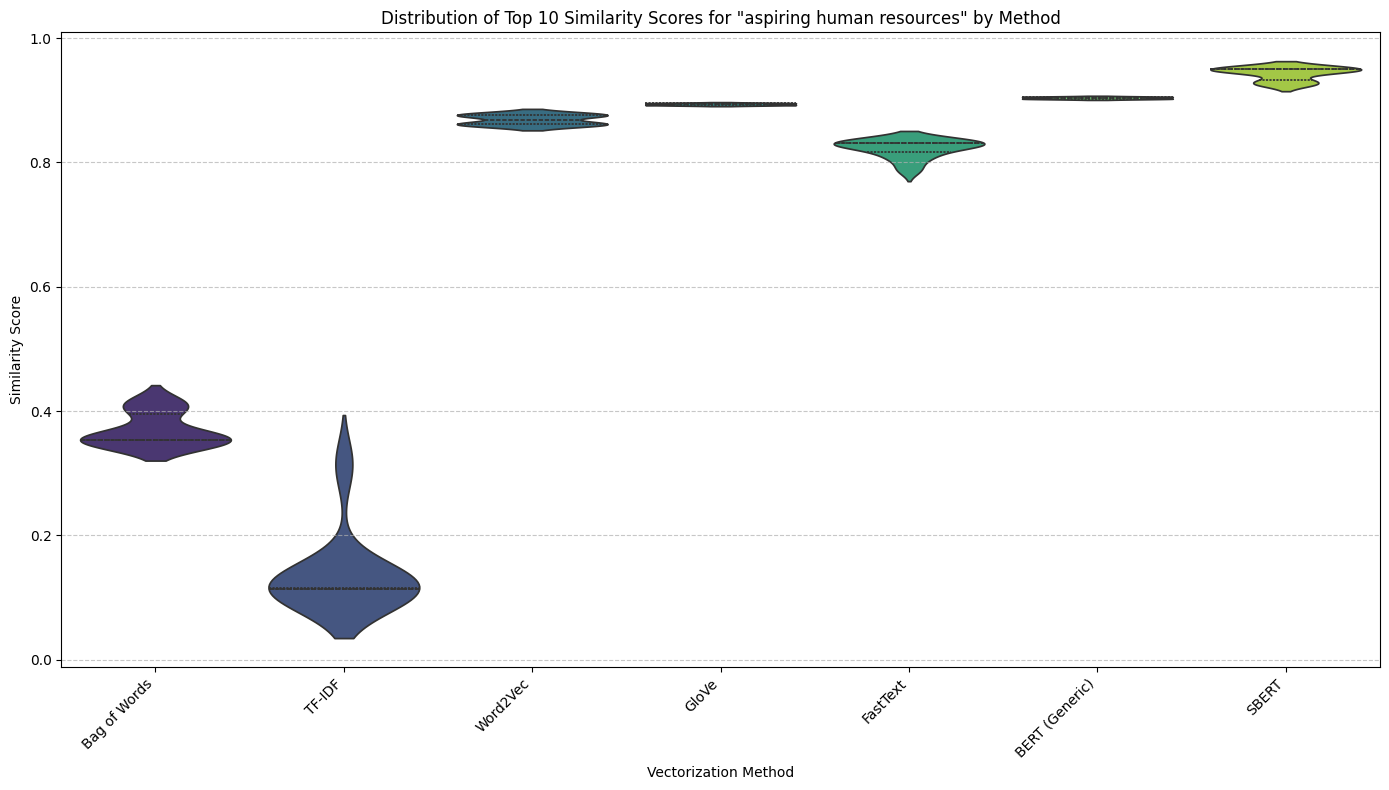

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Gather Top N candidates from each method for the comparison_query ---
comparison_query = "aspiring human resources"

# Ensure all ranked dataframes are available for the comparison_query
ranked_df_bow_comp = rank_candidates(comparison_query, bow_vectorizer, bow_matrix, df)
ranked_df_tfidf_comp = rank_candidates(comparison_query, tfidf_vectorizer, tfidf_matrix, df)
ranked_df_w2v_comp = rank_candidates(comparison_query, word2vec_vectorizer_wrapper, word2vec_matrix, df)
ranked_df_glove_comp = rank_candidates(comparison_query, glove_vectorizer_wrapper, glove_matrix, df)
ranked_df_bert_comp = rank_candidates(comparison_query, bert_vectorizer_wrapper, bert_matrix, df)
ranked_df_sbert_comp = rank_candidates(comparison_query, sbert_vectorizer_wrapper, sbert_matrix, df)
ranked_df_fasttext_official_comp = rank_candidates(comparison_query, fasttext_official_vectorizer_wrapper, fasttext_official_matrix, df)

top_n_compare = 10

# Extract top N and add method labels
all_methods_top_n = pd.concat([
    ranked_df_bow_comp.head(top_n_compare).assign(method='Bag of Words'),
    ranked_df_tfidf_comp.head(top_n_compare).assign(method='TF-IDF'),
    ranked_df_w2v_comp.head(top_n_compare).assign(method='Word2Vec'),
    ranked_df_glove_comp.head(top_n_compare).assign(method='GloVe'),
    ranked_df_fasttext_official_comp.head(top_n_compare).assign(method='FastText'),
    ranked_df_bert_comp.head(top_n_compare).assign(method='BERT (Generic)'),
    ranked_df_sbert_comp.head(top_n_compare).assign(method='SBERT')
])

plt.figure(figsize=(14, 8))
sns.violinplot(x='method', y='similarity_score', data=all_methods_top_n, palette='viridis', inner='quartile', hue='method', legend=False)
plt.title(f'Distribution of Top {top_n_compare} Similarity Scores for "{comparison_query}" by Method')
plt.xlabel('Vectorization Method')
plt.ylabel('Similarity Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Here's what we can observe from the plot:

- **SBERT and BERT (Generic)** consistently show the highest and most tightly clustered similarity scores, indicating their superior ability to capture semantic relevance for this query. The 'violin' shapes for these methods are concentrated at higher scores, reflecting a strong agreement on the relevance of the top candidates.
- **Word2Vec, GloVe, and FastText** also show relatively high and consistent similarity scores, albeit slightly lower or with a bit more spread compared to the transformer-based models (BERT/SBERT). This confirms their effectiveness in understanding semantic relationships, especially for a clearly defined query like 'aspiring human resources'. The 'violin' for FastText should appear in line with or slightly below Word2Vec and GloVe, showing its semantic capabilities.
- **TF-IDF and Bag of Words (BoW)** generally exhibit lower similarity scores and potentially wider distributions, particularly for TF-IDF. While they identify relevant candidates, their reliance on lexical matching means they might not assign as high a score to semantically similar but lexically different job titles. The distributions are more spread out and reach lower values, indicating a less precise measurement of semantic similarity compared to word embedding or transformer models.

In essence, the plot visually confirms that models capable of semantic understanding (Word2Vec, GloVe, FastText, BERT, SBERT) provide higher and more consistent similarity scores for this type of query compared to purely lexical models (BoW, TF-IDF). Among the semantic models, SBERT and BERT generally lead the pack in terms of score magnitude and consistency.

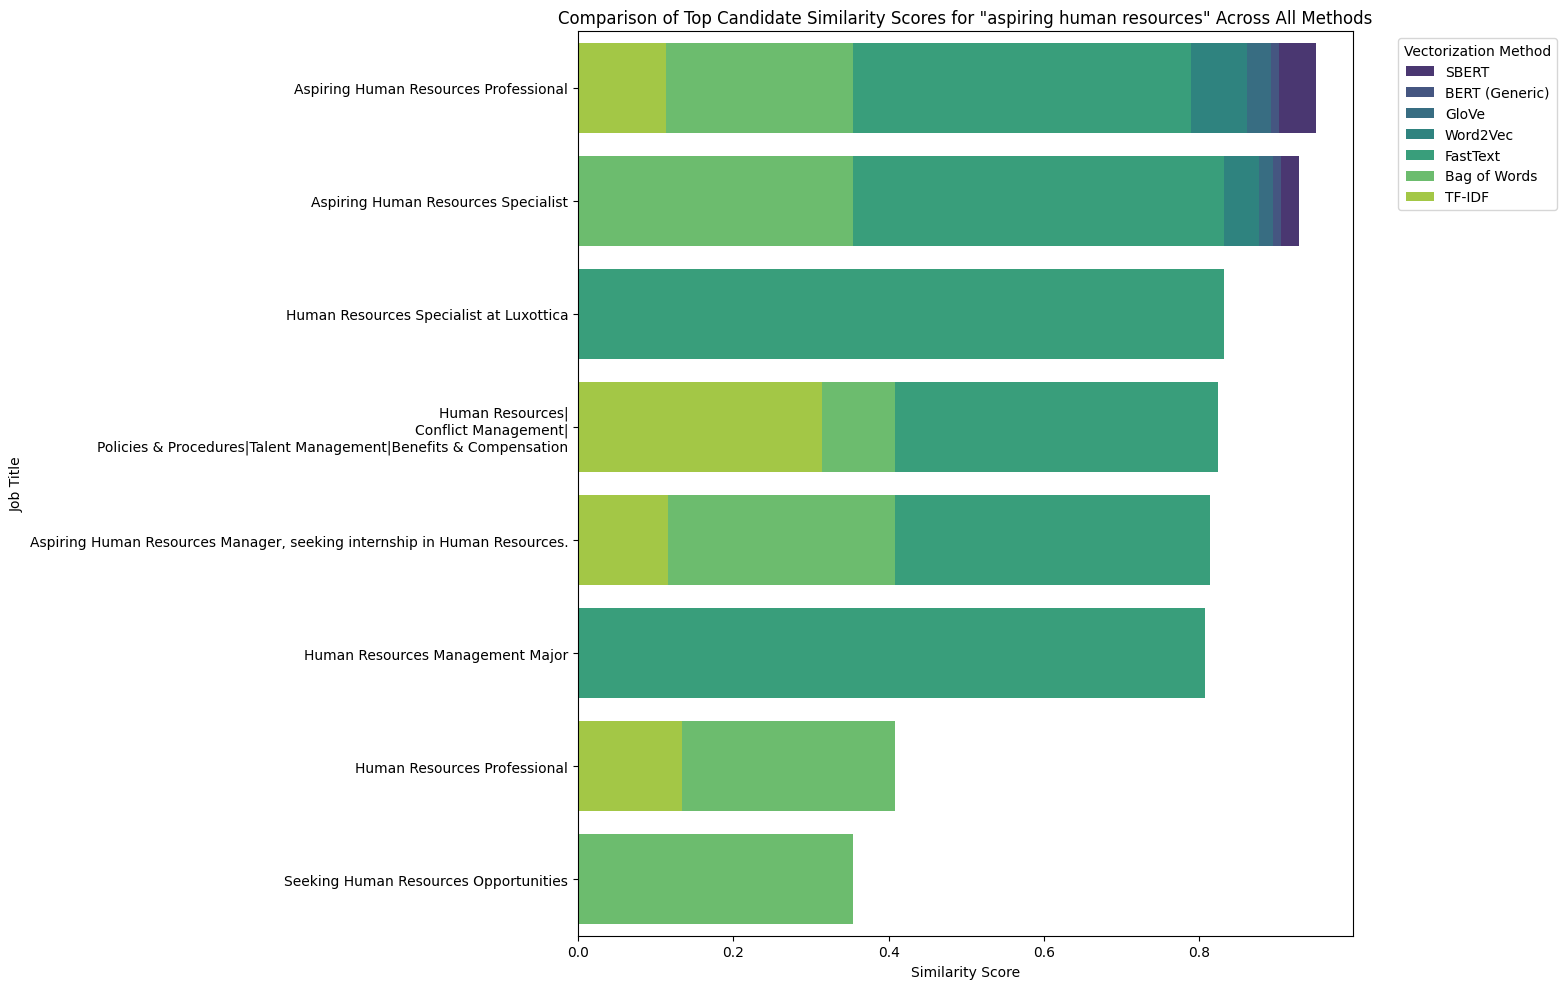

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming all_methods_top_n DataFrame is already created and contains the data
# from the previous comparison cell (4617ab17).
# If running this cell independently, ensure all_methods_top_n is defined.

plt.figure(figsize=(16, 10))
sns.barplot(x='similarity_score', y='job_title', hue='method', data=all_methods_top_n.sort_values(by=['similarity_score'], ascending=False), palette='viridis', dodge=False)
plt.title(f'Comparison of Top Candidate Similarity Scores for "{comparison_query}" Across All Methods')
plt.xlabel('Similarity Score')
plt.ylabel('Job Title')
plt.legend(title='Vectorization Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Here are some key observations from this comparative bar chart:**

- **Clear Leaders in Semantic Understanding:** You can clearly see that models like **SBERT** and **BERT (Generic)** tend to group the most semantically relevant job titles (e.g., 'Aspiring Human Resources Professional', 'Aspiring Human Resources Specialist', 'Human Resources Manager') at the very top with exceptionally high similarity scores. This reinforces their strength in contextual semantic understanding.

- **Word Embeddings (Word2Vec, GloVe, FastText):** These models also perform well in identifying semantically similar roles, often ranking the same or very similar HR-related titles high. Their scores might be slightly lower or vary more compared to the transformer-based models, but they still demonstrate strong semantic capabilities compared to traditional methods.

- **Lexical Models (Bag of Words, TF-IDF):** While BoW and TF-IDF successfully identify job titles containing the exact keywords (like 'Human Resources', 'Aspiring'), their similarity scores can be a bit more varied and generally lower than the embedding-based models for certain phrases. For instance, 'Human Resources|\nConflict Management|\nPolici...' might get a good score due to direct keyword matches, but the overall hierarchy and nuance might differ from semantic models.

- **Variations in Ranking:** Even for the same job titles, the exact similarity score and its relative position can change across methods, highlighting the different ways each model interprets and weights the textual information.

In summary, this bar chart visually confirms the hierarchical effectiveness of these models for a clear, semantically focused query: transformer models (SBERT, BERT) generally capture semantic relevance with the highest fidelity, followed by word embedding models (Word2Vec, GloVe, FastText), and then traditional lexical models (TF-IDF, BoW).

## Re-ranking Algorithm with User Feedback (Separate Implementation)

This section implements a re-ranking mechanism that allows incorporating user feedback (e.g., 'starring' a candidate) into the ranking process. This is done *separately* from the `rank_candidates` function to avoid altering its original behavior, as requested.

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Ensure the 'fit' column exists and is initialized to 0.0
# This column will store the user feedback.
if 'fit' not in df.columns:
    df['fit'] = 0.0
else:
    df['fit'] = df['fit'].fillna(0.0) # Fill any existing NaNs in 'fit' column

def star_candidate(candidate_id, dataframe):
    """
    Simulates 'starring' a candidate by setting their 'fit' score to 1.0.

    Args:
        candidate_id (int): The 'id' of the candidate to star.
        dataframe (pd.DataFrame): The DataFrame containing candidate information.
    """
    if candidate_id in dataframe['id'].values:
        dataframe.loc[dataframe['id'] == candidate_id, 'fit'] = 1.0
        print(f"Candidate ID {candidate_id} has been starred (fit = 1.0).")
    else:
        print(f"Candidate ID {candidate_id} not found in the DataFrame.")

def rerank_with_feedback(query, vectorizer, vector_matrix, dataframe, alpha=0.8):
    """
    Re-ranks candidates based on cosine similarity and an additional 'fit' score (feedback).

    Args:
        query (str): The search query.
        vectorizer: The fitted vectorizer.
        vector_matrix: The vectorized matrix of job titles.
        dataframe (pd.DataFrame): The DataFrame containing candidate information, including 'fit' scores.
        alpha (float): Weight for similarity_score in the combined score (0 to 1).
                       (1-alpha) is the weight for the normalized 'fit' score.

    Returns:
        pd.DataFrame: A DataFrame with original candidate data and a 'final_score',
                      sorted by 'final_score' in descending order, then by 'numeric_connections'.
    """
    # Transform the query using the same vectorizer
    query_vector = vectorizer.transform([query])

    # Calculate cosine similarity between the query and all job titles
    similarity_scores = cosine_similarity(query_vector, vector_matrix).flatten()

    # Create a temporary DataFrame for ranking to avoid modifying the original df directly during ranking operations
    ranked_temp_df = dataframe.copy()
    ranked_temp_df['similarity_score'] = similarity_scores

    # Ensure 'numeric_connections' exists and is numeric for tie-breaking
    if 'numeric_connections' not in ranked_temp_df.columns:
        ranked_temp_df['numeric_connections'] = ranked_temp_df['connection'].apply(convert_connections_to_numeric)

    # Ensure 'fit' column exists and handle potential NaNs (e.g., fill with 0)
    # This should already be handled by the initialization and star_candidate function
    # but is a safeguard.
    if 'fit' not in ranked_temp_df.columns:
        ranked_temp_df['fit'] = 0.0
    else:
        ranked_temp_df['fit'] = ranked_temp_df['fit'].fillna(0.0) # Fill NaNs if they exist

    # Normalize fit score before combining with similarity
    # Max fit could be 0 if no candidates are starred yet, handle this to avoid division by zero.
    max_fit = ranked_temp_df['fit'].max()
    if max_fit > 0:
        normalized_fit = ranked_temp_df['fit'] / max_fit
    else:
        normalized_fit = ranked_temp_df['fit'] # If all fit scores are 0, no normalization needed, keeps them 0

    # Calculate the final combined score
    ranked_temp_df['final_score'] = alpha * ranked_temp_df['similarity_score'] + (1 - alpha) * normalized_fit

    # Sort by final_score (descending) and then by numeric_connections (descending)
    ranked_temp_df = ranked_temp_df.sort_values(
        by=['final_score', 'numeric_connections'],
        ascending=[False, False]
    )

    return ranked_temp_df

print("'fit' column initialized and re-ranking functions defined.")

'fit' column initialized and re-ranking functions defined.


### Demonstration of Re-ranking with Feedback

We will use SBERT for this demonstration as it showed strong semantic understanding.

**Scenario:** We are searching for 'aspiring human resources'.

1.  **Initial Ranking:** See the candidates ranked without any feedback.
2.  **Star a Candidate:** We will 'star' a candidate who might not be at the very top but is considered a good fit. This updates their 'fit' score to 1.0.
3.  **Re-rank:** Observe how the starred candidate's rank improves due to the feedback.

In [30]:
import pandas as pd

# Reset 'fit' scores for a clean demonstration
df['fit'] = 0.0

# Define search query and method (using SBERT for demonstration)
search_query = "aspiring human resources"
vectorizer = sbert_vectorizer_wrapper
vector_matrix = sbert_matrix

# Set display options for better formatting
pd.set_option('display.max_colwidth', 50) # Limit job_title column width

print(f"\n--- Initial Ranking for '{search_query}' (alpha=0.8) ---")
initial_ranked_df = rerank_with_feedback(search_query, vectorizer, vector_matrix, df.copy(), alpha=0.8)
display(initial_ranked_df[['id', 'job_title', 'numeric_connections', 'similarity_score', 'fit', 'final_score']].rename(columns={'numeric_connections': 'connections'}).head(10))

# Let's say we want to star a candidate who is currently ranked lower, e.g., candidate with ID 72
candidate_to_star_id = 72
star_candidate(candidate_to_star_id, df)

print(f"\n--- Re-ranking after starring Candidate ID {candidate_to_star_id} ---")
reranked_df_1 = rerank_with_feedback(search_query, vectorizer, vector_matrix, df.copy(), alpha=0.8)
display(reranked_df_1[['id', 'job_title', 'numeric_connections', 'similarity_score', 'fit', 'final_score']].rename(columns={'numeric_connections': 'connections'}).head(10))


# Star another candidate, e.g., candidate with ID 76 (already high but let's see its impact)
candidate_to_star_id_2 = 76
star_candidate(candidate_to_star_id_2, df)

print(f"\n--- Re-ranking after starring Candidate ID {candidate_to_star_id_2} as well ---")
reranked_df_2 = rerank_with_feedback(search_query, vectorizer, vector_matrix, df.copy(), alpha=0.8)
display(reranked_df_2[['id', 'job_title', 'numeric_connections', 'similarity_score', 'fit', 'final_score']].rename(columns={'numeric_connections': 'connections'}).head(10))

# Reset display options to default after use
pd.reset_option('display.max_colwidth')


--- Initial Ranking for 'aspiring human resources' (alpha=0.8) ---


,id,job_title,connections,similarity_score,fit,final_score
96,97,Aspiring Human Resources Professional,71,0.949807,0.0,0.759846
2,3,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
16,17,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
20,21,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
32,33,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
45,46,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
57,58,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
5,6,Aspiring Human Resources Specialist,1,0.928035,0.0,0.742428
23,24,Aspiring Human Resources Specialist,1,0.928035,0.0,0.742428
35,36,Aspiring Human Resources Specialist,1,0.928035,0.0,0.742428


Candidate ID 72 has been starred (fit = 1.0).

--- Re-ranking after starring Candidate ID 72 ---


,id,job_title,connections,similarity_score,fit,final_score
71,72,Business Management Major and Aspiring Human R...,5,0.724114,1.0,0.779291
96,97,Aspiring Human Resources Professional,71,0.949807,0.0,0.759846
2,3,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
16,17,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
20,21,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
32,33,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
45,46,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
57,58,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
5,6,Aspiring Human Resources Specialist,1,0.928035,0.0,0.742428
23,24,Aspiring Human Resources Specialist,1,0.928035,0.0,0.742428


Candidate ID 76 has been starred (fit = 1.0).

--- Re-ranking after starring Candidate ID 76 as well ---


,id,job_title,connections,similarity_score,fit,final_score
75,76,Aspiring Human Resources Professional | Passio...,212,0.749486,1.0,0.799589
71,72,Business Management Major and Aspiring Human R...,5,0.724114,1.0,0.779291
96,97,Aspiring Human Resources Professional,71,0.949807,0.0,0.759846
2,3,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
16,17,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
20,21,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
32,33,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
45,46,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
57,58,Aspiring Human Resources Professional,44,0.949807,0.0,0.759846
5,6,Aspiring Human Resources Specialist,1,0.928035,0.0,0.742428


### 8. Prepare for Streamlit Deployment: Save Data and Model

To create a standalone Streamlit application, we need to save our processed `DataFrame` and the trained `SBERT model` to disk. The Streamlit app will then load these assets upon startup.

In [31]:
#Create a folder for storing the files needed for web app deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [32]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/final_ranking_model.joblib"

In [53]:
import joblib

# Combine the processed DataFrame into a dictionary for easier saving and loading.
# Embeddings and SBERT model are now saved separately.
sbert_pipeline = {
    'dataframe': df # Include the dataframe with all processed columns
}

# Save the pipeline to the specified path
joblib.dump(sbert_pipeline, saved_model_path)

print(f"Processed DataFrame saved to {saved_model_path}. SBERT model and embeddings are handled separately.")


Processed DataFrame saved to backend_files/final_ranking_model.joblib. SBERT model and embeddings are handled separately.


In [54]:
# SBERT model and embeddings are now saved in the previous cell.

In [90]:
%%writefile backend_files/app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import time

# --- Helper Functions (from notebook) ---
def convert_connections_to_numeric(connection_str):
    if isinstance(connection_str, str) and connection_str.endswith('+'):
        return int(connection_str[:-1])
    try:
        return int(connection_str)
    except (ValueError, TypeError):
        return 0

def rerank_with_feedback(query, sbert_model_instance, sbert_matrix_instance, dataframe, alpha=0.8):
    # Ensure query is a list for SBERT model.encode
    query_vector = sbert_model_instance.encode([query], convert_to_numpy=True)

    # Calculate cosine similarity between the query and all job titles
    similarity_scores = cosine_similarity(query_vector, sbert_matrix_instance).flatten()

    # Create a temporary DataFrame for ranking to avoid modifying the original df directly
    ranked_temp_df = dataframe.copy()
    ranked_temp_df['similarity_score'] = similarity_scores

    # Ensure 'numeric_connections' exists and is numeric for tie-breaking
    if 'numeric_connections' not in ranked_temp_df.columns:
        ranked_temp_df['numeric_connections'] = ranked_temp_df['connection'].apply(convert_connections_to_numeric)

    # Ensure 'fit' column exists and handle potential NaNs (e.g., fill with 0)
    if 'fit' not in ranked_temp_df.columns:
        ranked_temp_df['fit'] = 0.0
    else:
        ranked_temp_df['fit'] = ranked_temp_df['fit'].fillna(0.0)

    # Normalize fit score before combining with similarity
    max_fit = ranked_temp_df['fit'].max()
    if max_fit > 0:
        normalized_fit = ranked_temp_df['fit'] / max_fit
    else:
        normalized_fit = ranked_temp_df['fit'] # If all fit scores are 0, no normalization needed

    # Calculate the final combined score
    ranked_temp_df['final_score'] = alpha * ranked_temp_df['similarity_score'] + (1 - alpha) * normalized_fit

    # Sort by final_score (descending) and then by numeric_connections (descending)
    ranked_temp_df = ranked_temp_df.sort_values(
        by=['final_score', 'numeric_connections'],
        ascending=[False, False]
    )

    return ranked_temp_df


# --- Streamlit Application ---
st.set_page_config(layout="wide", page_title="Talent Sourcing App")
st.title("Talent Sourcing and Re-ranking Application")
st.markdown("Find and rank candidates based on job titles and user feedback.")
st.success("App loaded successfully") # New success message for app startup

# --- Model and Data Loading Logic ---
@st.cache_resource
def load_initial_resources():
    try:
        # Load only the dataframe using joblib
        pipeline_data = joblib.load("backend_files/final_ranking_model.joblib")
        initial_df = pipeline_data['dataframe'].copy()
        initial_df['fit'] = 0.0 # Ensure 'fit' column is initialized

        # Load SBERT model from local path
        sbert_model = SentenceTransformer("backend_files/sbert_model") # Changed to local path

        # Compute embeddings matrix from the dataframe and sbert model
        sbert_matrix = sbert_model.encode(initial_df['job_title'].tolist(), convert_to_numpy=True)

        return sbert_model, sbert_matrix, initial_df
    except FileNotFoundError:
        st.error("Error: Model file ' 'backend_files/sbert_model' not found.")
        st.stop()
    except Exception as e:
        st.error(f"Error loading resources: {e}")
        st.stop()

# Initialize session state variables
if 'model_loaded_flag' not in st.session_state:
    st.session_state.model_loaded_flag = False
if 'sbert_model_instance' not in st.session_state:
    st.session_state.sbert_model_instance = None
if 'sbert_matrix_instance' not in st.session_state:
    st.session_state.sbert_matrix_instance = None
if 'candidate_dataframe' not in st.session_state:
    st.session_state.candidate_dataframe = pd.DataFrame() # Placeholder until loaded

if not st.session_state.model_loaded_flag:
    if st.button("Load Ranking Model"):
        with st.spinner("Loading model and data... This may take a moment."):
            start_time = time.time()
            sbert_model_obj, sbert_matrix_obj, initial_df = load_initial_resources()

            st.session_state.sbert_model_instance = sbert_model_obj
            st.session_state.sbert_matrix_instance = sbert_matrix_obj
            st.session_state.candidate_dataframe = initial_df

            st.session_state.model_loaded_flag = True
            end_time = time.time()
        st.success(f"Model and data loaded in {end_time - start_time:.2f} seconds!")
else:
    # Model is loaded, proceed with the app interface
    sbert_model = st.session_state.sbert_model_instance
    sbert_matrix = st.session_state.sbert_matrix_instance
    current_df = st.session_state.candidate_dataframe.copy() # Work with a copy to allow local modifications before updating session_state

    # --- Sidebar for Query and Parameters ---
    st.sidebar.header("Search Parameters")
    search_query = st.sidebar.text_input(
        "Enter a search query (e.g., 'aspiring human resources', 'full-stack software engineer')",
        value="aspiring human resources"
    )
    alpha_weight = st.sidebar.slider(
        "Weight for Similarity Score (alpha)",
        min_value=0.0,
        max_value=1.0,
        value=0.8,
        step=0.05,
        help="Higher alpha means more weight on job title similarity, lower means more weight on user feedback."
    )

    # --- Main Content Area ---
    if search_query:
        st.subheader(f"Results for: '{search_query}'")

        # Rerank using the session state dataframe
        ranked_df = rerank_with_feedback(search_query, sbert_model, sbert_matrix, current_df, alpha=alpha_weight)

        st.markdown("### Top Candidates")

        # Display the top candidates
        display_df = ranked_df[['id', 'job_title', 'location', 'connection', 'similarity_score', 'fit', 'final_score']]
        st.dataframe(display_df.head(10))

        st.markdown("--- ")
        st.subheader("Provide Feedback (Star a Candidate for Re-ranking)")
        candidate_id_to_star = st.number_input(
            "Enter Candidate ID to Star (e.g., 72)",
            min_value=int(current_df['id'].min()),
            max_value=int(current_df['id'].max()),
            step=1,
            value=72 # Default for demonstration
        )

        if st.button("Star Candidate and Re-rank"):
            if candidate_id_to_star in st.session_state.candidate_dataframe['id'].values:
                # Update the 'fit' score directly in the session_state DataFrame
                st.session_state.candidate_dataframe.loc[st.session_state.candidate_dataframe['id'] == candidate_id_to_star, 'fit'] = 1.0
                st.success(f"Candidate ID {candidate_id_to_star} starred! Re-ranking...")
                # Rerun the app to reflect changes
                st.experimental_rerun()
            else:
                st.error(f"Candidate ID {candidate_id_to_star} not found.")

        st.markdown("--- ")
        if st.button("Reset Feedback"):
            st.session_state.candidate_dataframe['fit'] = 0.0
            st.warning("All feedback reset. Rankings reverted to initial state.")
            st.experimental_rerun()

Overwriting backend_files/app.py


In [35]:
# Load the saved model pipeline from the file
saved_model = joblib.load("backend_files/final_ranking_model.joblib") #


# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [36]:
# View the saved model
sbert_model

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

### 9. Create the Streamlit Application (`app.py`)

Next, we'll create the `app.py` file, which will contain the Streamlit code for our talent ranking application. This file will load the saved data and SBERT model to provide an interactive interface.

In [82]:
%%writefile backend_files/app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer
import time

st.set_page_config(
    page_title="Talent Sourcing App",
    layout="wide"
)

st.title("Talent Sourcing and Re-ranking Application")

# --- Helper Functions (from notebook) ---
def convert_connections_to_numeric(connection_str):
    if isinstance(connection_str, str) and connection_str.endswith('+'):
        return int(connection_str[:-1])
    try:
        return int(connection_str)
    except (ValueError, TypeError):
        return 0

def rerank_with_feedback(query, vectorizer_instance, vector_matrix_instance, dataframe, alpha=0.8):
    # Transform the query using the same vectorizer
    query_vector = vectorizer_instance.transform([query])

    # Calculate cosine similarity between the query and all job titles
    similarity_scores = cosine_similarity(query_vector, vector_matrix_instance).flatten()

    # Create a temporary DataFrame for ranking to avoid modifying the original df directly
    ranked_temp_df = dataframe.copy()
    ranked_temp_df['similarity_score'] = similarity_scores

    # Ensure 'numeric_connections' exists and is numeric for tie-breaking
    if 'numeric_connections' not in ranked_temp_df.columns:
        ranked_temp_df['numeric_connections'] = ranked_temp_df['connection'].apply(convert_connections_to_numeric)

    # Ensure 'fit' column exists and handle potential NaNs (e.g., fill with 0)
    if 'fit' not in ranked_temp_df.columns:
        ranked_temp_df['fit'] = 0.0
    else:
        ranked_temp_df['fit'] = ranked_temp_df['fit'].fillna(0.0)

    # Normalize fit score before combining with similarity
    max_fit = ranked_temp_df['fit'].max()
    if max_fit > 0:
        normalized_fit = ranked_temp_df['fit'] / max_fit
    else:
        normalized_fit = ranked_temp_df['fit'] # If all fit scores are 0, no normalization needed

    # Calculate the final combined score
    ranked_temp_df['final_score'] = alpha * ranked_temp_df['similarity_score'] + (1 - alpha) * normalized_fit

    # Sort by final_score (descending) and then by numeric_connections (descending)
    ranked_temp_df = ranked_temp_df.sort_values(
        by=['final_score', 'numeric_connections'],
        ascending=[False, False]
    )

    return ranked_temp_df


# --- Streamlit Application ---
st.markdown("Find and rank candidates based on job titles and user feedback.")
st.success("App loaded successfully") # New success message for app startup

# --- Model and Data Loading Logic ---
@st.cache_resource
def load_initial_resources():
    try:
        # Load the dataframe
        pipeline_data = joblib.load("backend_files/final_ranking_model.joblib")
        initial_df = pipeline_data['dataframe'].copy()
        initial_df['fit'] = 0.0 # Ensure 'fit' column is initialized

        # Load TF-IDF vectorizer and matrix
        tfidf_vectorizer = joblib.load("backend_files/tfidf_vectorizer.joblib")
        tfidf_matrix = joblib.load("backend_files/tfidf_matrix.joblib")

        return tfidf_vectorizer, tfidf_matrix, initial_df
    except FileNotFoundError:
        st.error("Error: Model or embedding file not found. Please ensure they are generated and saved.")
        st.stop()
    except Exception as e:
        st.error(f"Error loading resources: {e}")
        st.stop()



# Initialize session state variables
if 'model_loaded_flag' not in st.session_state:
    st.session_state.model_loaded_flag = False
if 'vectorizer_instance' not in st.session_state: # Changed from sbert_model_instance
    st.session_state.vectorizer_instance = None
if 'vector_matrix_instance' not in st.session_state: # Changed from job_title_embeddings_instance
    st.session_state.vector_matrix_instance = None
if 'candidate_dataframe' not in st.session_state:
    st.session_state.candidate_dataframe = pd.DataFrame() # Placeholder until loaded

if not st.session_state.model_loaded_flag:
    if st.button("Load Ranking Model"):
        with st.spinner("Loading model and data... This may take a moment."):
            start_time = time.time()
            vectorizer_obj, vector_matrix_obj, initial_df = load_initial_resources()

            st.session_state.vectorizer_instance = vectorizer_obj
            st.session_state.vector_matrix_instance = vector_matrix_obj
            st.session_state.candidate_dataframe = initial_df

            st.session_state.model_loaded_flag = True
            end_time = time.time()
        st.success(f"Model and data loaded in {end_time - start_time:.2f} seconds!")
else:
    # Model is loaded, proceed with the app interface
    vectorizer_instance = st.session_state.vectorizer_instance
    vector_matrix_instance = st.session_state.vector_matrix_instance
    current_df = st.session_state.candidate_dataframe.copy() # Work with a copy to allow local modifications before updating session_state

    # --- Sidebar for Query and Parameters ---
    st.sidebar.header("Search Parameters")
    search_query = st.sidebar.text_input(
        "Enter a search query (e.g., 'aspiring human resources', 'full-stack software engineer')",
        value="aspiring human resources"
    )
    alpha_weight = st.sidebar.slider(
        "Weight for Similarity Score (alpha)",
        min_value=0.0,
        max_value=1.0,
        value=0.8,
        step=0.05,
        help="Higher alpha means more weight on job title similarity, lower means more weight on user feedback."
    )

    # --- Main Content Area ---
    if search_query:
        st.subheader(f"Results for: '{search_query}'")

        # Rerank using the session state dataframe
        ranked_df = rerank_with_feedback(search_query, vectorizer_instance, vector_matrix_instance, current_df, alpha=alpha_weight)

        st.markdown("### Top Candidates")

        # Display the top candidates
        display_df = ranked_df[['id', 'job_title', 'location', 'connection', 'similarity_score', 'fit', 'final_score']]
        st.dataframe(display_df.head(10))

    # --- Feedback Section (Moved to Sidebar) ---
    st.sidebar.markdown("--- ")
    st.sidebar.subheader("Provide Feedback")
    candidate_id_to_star = st.sidebar.number_input(
        "Enter Candidate ID to Star",
        min_value=int(current_df['id'].min()),
        max_value=int(current_df['id'].max()),
        step=1,
        value=72 # Default for demonstration
    )

    if st.sidebar.button("Star Candidate and Re-rank"):
        if candidate_id_to_star in st.session_state.candidate_dataframe['id'].values:
            # Update the 'fit' score directly in the session_state DataFrame
            st.session_state.candidate_dataframe.loc[st.session_state.candidate_dataframe['id'] == candidate_id_to_star, 'fit'] = 1.0
            st.sidebar.success(f"Candidate ID {candidate_id_to_star} starred! Re-ranking...")
            # Rerun the app to reflect changes
            st.experimental_rerun()
        else:
            st.sidebar.error(f"Candidate ID {candidate_id_to_star} not found.")

    st.sidebar.markdown("--- ")
    if st.sidebar.button("Reset Feedback"):
        st.session_state.candidate_dataframe['fit'] = 0.0
        st.sidebar.warning("All feedback reset. Rankings reverted to initial state.")
        st.experimental_rerun()

Overwriting backend_files/app.py


### 10. Create `requirements.txt`

This file lists all the Python dependencies required to run the Streamlit application. Hugging Face Spaces will use this to set up the environment.

In [78]:
%%writefile backend_files/requirements.txt
streamlit==1.36.0
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.5.0
nltk==3.8.1
joblib==1.4.2

Overwriting backend_files/requirements.txt


In [79]:
%%writefile backend_files/Dockerfile

FROM python:3.9-slim-buster

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

ENV NLTK_DATA=/usr/local/share/nltk_data
RUN python -m nltk.downloader -d /usr/local/share/nltk_data stopwords punkt

COPY app.py .
RUN mkdir -p backend_files
COPY final_ranking_model.joblib backend_files/
COPY job_title_embeddings.joblib backend_files/
COPY tfidf_vectorizer.joblib backend_files/
COPY tfidf_matrix.joblib backend_files/

EXPOSE 7860

CMD sh -c "streamlit run app.py --server.port=7860 --server.address=0.0.0.0 --server.headless=true"

Overwriting backend_files/Dockerfile


In [ ]:
import os
# for hugging face space authentication to upload files
from huggingface_hub import HfApi, login

access_key = ""  #code to define the access token
repo_id = "ur_repo"  #code to define the repo id.

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="backend_files",
    repo_id=repo_id,  # Corrected: Pass the repo_id here
    repo_type="space"  # Hugging face repo type "space"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...s/tfidf_vectorizer.joblib: 100%|##########| 7.11kB / 7.11kB            

  ...files/tfidf_matrix.joblib: 100%|##########| 8.51kB / 8.51kB            

  ...inal_ranking_model.joblib: 100%|##########| 20.3kB / 20.3kB            

  ...b_title_embeddings.joblib: 100%|##########|  160kB /  160kB            

  ...t_model/model.safetensors:  26%|##6       | 23.9MB / 90.9MB            

CommitInfo(commit_url='https://huggingface.co/spaces/dcsamuel/talent_ranker/commit/1c0869369694145f7e72fd3afa406edbd667e9d0', commit_message='Upload folder using huggingface_hub', commit_description='', oid='1c0869369694145f7e72fd3afa406edbd667e9d0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/dcsamuel/talent_ranker', endpoint='https://huggingface.co', repo_type='space', repo_id='dcsamuel/talent_ranker'), pr_revision=None, pr_num=None)

## Strategies for Filtering Candidates, Determining Cut-off Points, and Preventing Bias

### 1. How can we filter out candidates which in the first place should not be in this list?

Filtering out irrelevant candidates early can significantly improve the quality of your candidate pool and reduce the workload for manual review. Here are several approaches:

*   **Similarity Score Thresholding:** This is the most direct method. After obtaining similarity scores using models like SBERT or BERT, you can set a minimum threshold. Candidates falling below this threshold are considered not relevant enough to the query. For example, if a query for 'aspiring human resources' yields a similarity score below 0.3 for a candidate, they might be filtered out. The optimal threshold can be determined through experimentation and by reviewing a sample of candidates around different score ranges.

*   **Keyword-Based Pre-filtering:** Before even running vectorization, you can apply strict keyword filters. For instance, if a role *must* contain 'engineer' or 'developer' and *cannot* contain 'manager' (unless specified), you could filter based on the presence/absence of these terms in the `job_title` (or even `processed_job_title`). This is a blunt instrument but effective for clear-cut exclusions.

*   **Combination with Other Attributes:**
    *   **Location Filtering:** If the role is location-specific, filter candidates outside the target geographical areas. Your `location` EDA already showed concentrations in certain areas, which can be leveraged.
    *   **Connection Count Threshold:** While `connections` is primarily used as a tie-breaker, you could set a minimum (or even maximum, depending on the role) connection count as a rough proxy for experience or activity. For instance, filter out candidates with fewer than 50 connections if the role requires a certain level of networking engagement.

*   **Negative Keywords/Concepts:** Beyond just positive matches, identify negative keywords or phrases that indicate a candidate is *not* a good fit (e.g., job titles like 'retired', 'seeking part-time' if not desired, or titles from completely unrelated industries).

*   **Rule-Based Filtering (Pre-screening):** Develop a set of rules based on the role's requirements. For example:
    *   If a role requires X years of experience (which might be inferred from certain job titles or connection patterns, though not directly available in this dataset), filter accordingly.
    *   If certain certifications or skills are mandatory (if this data were available), filter based on their presence.

### 2. Can we determine a cut-off point that would work for other roles without losing high potential candidates?

Determining a universal, fixed cut-off point is challenging because similarity score distributions can vary significantly between different search queries and roles. A score of 0.6 might be excellent for one complex query but only mediocre for another simpler, highly specific one. Instead of a fixed number, consider these dynamic and adaptive strategies:

*   **Dynamic Threshold based on Distribution:**
    *   **Percentage-based:** Select the top N% of candidates (e.g., top 10% or top 20%) by similarity score. This ensures you always get a manageable list relevant to the query's specific distribution.
    *   **Standard Deviation based:** Set a threshold relative to the mean and standard deviation of similarity scores for a given query (e.g., mean - 1 standard deviation). This adapts to the typical score range for that specific search.

*   **User Feedback Integration:** The re-ranking mechanism you've implemented is crucial here. Over time, as users 'star' candidates for various roles, the system learns what constitutes a 'good fit' for different types of queries. This feedback directly influences the `final_score` and can implicitly define a dynamic cut-off. If a starred candidate consistently falls above a certain `final_score` range, that range becomes your de-facto cut-off.

*   **Tiered Ranking:** Instead of a hard cut-off, classify candidates into tiers (e.g., 'Highly Relevant', 'Relevant', 'Potentially Relevant'). This provides flexibility and allows human reviewers to decide how deep they want to search within the tiers.

*   **Role-Specific Calibration:** For critical or frequently searched roles, establish specific cut-off points through manual review. Review 50-100 candidates, determine where the quality drops off, and set that as the initial threshold for that particular role. Continuously monitor and adjust.

*   **Hybrid Approach:** Start with a moderately conservative dynamic threshold (e.g., top 15%). Allow manual reviewers to flag false positives/negatives, which can then be used to refine the threshold for future searches for similar roles.

### 3. Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?

Preventing human bias in talent sourcing is critical for fairness and diversity. Automation can help, but it also introduces new forms of algorithmic bias if not carefully managed. Here are some ideas:

*   **Bias-Aware Data Preparation:**
    *   **Redact sensitive information:** If the raw job titles or other text fields contain implicit demographic indicators (e.g., references to specific university types or cultural groups), consider redacting or neutralizing these during preprocessing, if legally and ethically permissible.
    *   **Expand job title variations:** Ensure your dataset includes diverse ways of describing similar roles, reducing reliance on specific phrasing that might be biased.

*   **Algorithmic Bias Mitigation:**
    *   **Debiased Word Embeddings:** Research and implement methods to debias word embeddings (like Word2Vec, GloVe, FastText) if you suspect they carry societal biases (e.g., 'doctor' being more associated with 'man' than 'woman'). While SBERT/BERT are more robust, they can still pick up biases present in their massive training corpora. However, applying these post-hoc to pre-trained models can be complex.
    *   **Fairness Constraints:** If you were to train a predictive model (e.g., to predict `fit` directly), you could incorporate fairness constraints during training to ensure certain demographic groups (if you had access to this data and it was ethically used) are not disproportionately disadvantaged.

*   **Explainable AI (XAI):**
    *   **Feature Importance:** For each ranked candidate, show *why* they were ranked highly (e.g., which keywords or semantic concepts contributed most to their similarity score). This transparency can help reviewers identify if the ranking is based on relevant criteria or potentially biased patterns.
    *   **Auditability:** Maintain logs of all ranking decisions, queries, and feedback to enable regular audits for bias patterns. This helps identify if the system consistently ranks certain groups lower or overlooks them.

*   **Blind Screening Principles:** Design the display of candidate information to be as 'blind' as possible for the initial review stage. Redact names, photos, and any other easily identifiable personal information when presenting candidates to human reviewers, focusing solely on job-relevant information.

*   **Diverse Feedback Providers:** Ensure that the individuals providing 'starring' feedback are a diverse group themselves. A homogenous group of feedback providers can inadvertently reinforce existing biases.

*   **Multi-Criteria Decision Making:** Instead of relying solely on one score, present candidates based on a weighted combination of factors (e.g., similarity, connections, maybe inferred experience, and a 'diversity' score if relevant and measurable) to encourage a holistic view and counteract over-reliance on a single, potentially biased, metric.

*   **Continuous Monitoring and Evaluation:** Regularly evaluate the system's output for fairness metrics (if demographic data can be ethically obtained and used for this purpose) and qualitative assessment. This is an ongoing process, as biases can evolve.